# P&ID Digitization with a Relation-aware Deformable DETR (PIDFormer)

This notebook trains a PyTorch model that reads a **Piping & Instrumentation Diagram (P&ID)** image and returns, for every
piece of equipment / symbol:

* its **bounding box** (and **center x, y**),
* its **symbol class** (32 Digitize-PID classes, plus the 7 coarse classes used in the paper),
* its **tag name** (e.g. `WX-71994`, `GLR-193`) — from EasyOCR and/or Claude Sonnet 5.5 vision,
* the **list of equipment it is connected to** (pipe graph) — from a Relationformer relation head and/or Claude.

Final output is a JSON per sheet:
```json
{"sheet": "0.jpg", "equipment": [{"id": 3, "tag": "WX-71994", "class_name": "valve_bowtie_filled",
  "bbox": [x1, y1, x2, y2], "center": [cx, cy], "confidence": 0.97, "connected_to": [7, 12]}], "connections": [...]}
```

## Reference paper
Stürmer, Graumann, Koch — *From Engineering Diagrams to Graphs: Digitizing P&IDs with Transformers*
([arXiv:2411.13929](https://arxiv.org/abs/2411.13929), DSAA 2025). Key ideas reproduced here:

| Paper | This notebook |
|---|---|
| Relationformer = Deformable DETR + `[rln]` relation token + pairwise relation MLP | ✅ same structure (`PIDFormer`) |
| Patching of the full diagram with ≥50 % overlap, per-patch inference | ✅ random crops for training, 50 % overlapping tiles at inference |
| Merge: border-distance confidence decay → filtering → NMS → Weighted Box Fusion | ✅ implemented (`merge_tile_detections`) |
| EasyOCR for text | ✅ plus Claude vision for tag reading |
| Metrics: symbol mAP@0.5, class-agnostic node AP, edge mAP (Hungarian node matching) | ✅ implemented |
| ResNet-101, 512² patches, lr 1e-4 / backbone 3e-5 | ResNet-50 (configurable), 1024² patches (symbols are tiny) |

## Improvements over the paper (post-2024 detection-transformer practice)
1. **Contrastive DeNoising (CDN, DINO)** — noised copies of ground-truth boxes are fed as extra queries; positives must be
   reconstructed, *negatives* (larger noise) must be rejected. Stabilises bipartite matching and speeds convergence a lot on small datasets.
2. **Two-stage mixed query selection (DINO)** — decoder anchors are initialised from the top-K encoder proposals.
3. **Look-forward-twice box refinement (DINO)** — gradients from layer *i+1* refine layer *i*'s boxes.
4. **Varifocal / IoU-aware classification loss (RT-DETR, DEIM, D-FINE)** — classification target is the IoU of the matched box,
   so confidence ranks localisation quality (important for WBF merging of tiles).
5. **Supervised contrastive learning on query embeddings (SupCon + cross-batch memory)** — the paper's main failure mode is
   confusion between visually similar symbols (their "general" class; our 14 near-identical valve glyphs). A projection head pulls
   together decoder embeddings of the same class across images and pushes apart different classes. The embeddings are also exported
   (t-SNE in §9, few-shot prototype matching).
6. **Efficient hybrid encoder (RT-DETR)**: global self-attention on stride-32 tokens plus CNN cross-scale fusion. It replaces the
   6-layer deformable encoder, which is ~10× slower in pure PyTorch; the paper's encoder stays available via `cfg.encoder`.
7. **EMA weights, bf16 autocast, cosine LR with warmup, scale/rotation/flip/photometric augmentation**.
8. **Claude Sonnet 5.5 as a labeler and a refiner** — the HF dataset contains *only* symbol boxes. Claude reads set-of-marks overlays
   (numbered boxes drawn on the image) to produce tag names and pipe connections; these pseudo-labels train the relation head and
   are also used at inference to refine tags/connections.

## Datasets (combined)
1. [`hamzas/digitize-pid-yolo`](https://huggingface.co/datasets/hamzas/digitize-pid-yolo) is the synthetic *Dataset-P&ID* of
   Paliwal et al. (Digitize-PID, 2021): 500 sheets of 7168×4561 px, 32 symbol classes, YOLO boxes, 400 train / 100 val, ~119 symbols per sheet.
2. [Zenodo 8028570 `PID_dataset`](https://zenodo.org/records/8028570) (Gupta et al., ASU, CC-BY-4.0) holds **92 real-world P&IDs**
   from industry and web scraping (72 train / 20 test), with 4,302 YOLO boxes of a single class, `Symbol`. It is converted to the HF layout
   (§2b): sheets are rescaled so the median symbol matches the synthetic data (~72 px), and labels become class id 32 `symbol_unspecified`.
   These boxes teach *where* symbols are on real drawings; their class is left free (partial-label loss, §6). The paper's ablation (Table A5)
   shows that adding real sheets to synthetic training is the single biggest gain on real drawings.

## Pipeline
```
sheet ──► tile (1024², 50% overlap) ──► PIDFormer ──► per-tile boxes, classes, embeddings, pairwise edge logits
                                                   └► merge (decay → WBF → NMS) ──► sheet graph nodes + edges
sheet ──► EasyOCR (0/90/270°) ──► text boxes ──► Hungarian tag↔symbol assignment
(optional) set-of-marks overlay ──► Claude Sonnet 5.5 ──► tags + connections ──► fused graph ──► JSON
```

**Run order:** top to bottom. Set `SMOKE = True` (or env `PID_SMOKE=1`) for a 5-minute end-to-end check before the full run.
Claude steps are skipped automatically if no Anthropic credentials are configured (`ANTHROPIC_API_KEY`).

In [1]:
# Dependencies (already satisfied in most envs; uncomment to install)
# %pip install -q torch torchvision timm torchmetrics pycocotools huggingface_hub opencv-python-headless easyocr anthropic scikit-learn matplotlib

In [2]:
import os, json, math, time, random, copy, glob, re, base64, io
from pathlib import Path
from dataclasses import dataclass, field, asdict
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from multiprocessing import Pool

import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.ops import box_iou, generalized_box_iou, nms, batched_nms
from torchvision.ops.misc import FrozenBatchNorm2d
from scipy.optimize import linear_sum_assignment
import timm
import matplotlib.pyplot as plt

SMOKE = os.environ.get("PID_SMOKE", "0") == "1"   # quick end-to-end test run

@dataclass
class Config:
    # paths
    root: Path = Path.cwd()
    hf_repo: str = "hamzas/digitize-pid-yolo"
    data_dir: Path = Path.cwd() / "data" / "digitize-pid-yolo"
    zenodo_url: str = "https://zenodo.org/api/records/8028570/files/PID_Dataset.zip/content"
    zenodo_raw: Path = Path.cwd() / "data" / "zenodo_8028570"
    zenodo_dir: Path = Path.cwd() / "data" / "zenodo-pid-yolo"   # converted, HF-style layout
    target_symbol_px: float = 72.0   # median symbol size (native px) of the synthetic set; real sheets are rescaled to it
    zenodo_sample_frac: float = 0.3  # fraction of training crops drawn from real (Zenodo) sheets
    cache_dir: Path = Path.cwd() / "data" / "cache"
    run_dir: Path = Path.cwd() / "runs" / "pidformer"
    out_dir: Path = Path.cwd() / "outputs"
    # image geometry
    input_scale: float = 0.75     # sheets are resized by this factor before tiling (7168x4561 -> 5376x3421)
    tile: int = 1024              # model input size (square patch)
    infer_stride: int = 512       # 50% overlap at inference (paper: >= 50%)
    min_visible: float = 0.5      # keep a cropped GT box if >= this fraction is inside the patch
    # model
    num_classes: int = 32
    backbone: str = "resnet50"    # any timm model with features_only (e.g. resnet101 as in the paper, convnext_tiny)
    d_model: int = 256
    n_heads: int = 8
    n_levels: int = 3             # strides 8/16/32 (largest symbol ~120 px after scaling -> no stride-64 level needed)
    n_points: int = 4
    encoder: str = "hybrid"       # "hybrid" (RT-DETR efficient encoder) or "deformable" (paper)
    enc_layers: int = 1           # hybrid: transformer layers on C5 (use 6 for "deformable")
    dec_layers: int = 6
    ffn_dim: int = 1024
    num_queries: int = 300
    emb_dim: int = 128            # contrastive projection size
    # denoising
    dn_number: int = 100
    dn_label_noise: float = 0.5
    dn_box_noise: float = 1.0
    # loss weights (paper Table A1 uses box 2 / cls 2 / edge 3 for Relationformer)
    w_cls: float = 1.0
    w_l1: float = 5.0
    w_giou: float = 2.0
    w_supcon: float = 0.2
    w_rel: float = 1.0
    supcon_temp: float = 0.1
    supcon_queue: int = 4096
    # optimisation
    batch_size: int = 8
    epochs: int = 40
    iters_per_epoch: int = 500
    lr: float = 1e-4
    lr_backbone: float = 1e-5
    weight_decay: float = 1e-4
    warmup_iters: int = 1000
    clip_grad: float = 0.1
    ema_decay: float = 0.9998
    num_workers: int = 12
    eval_every: int = 2
    eval_val_sheets: int = 25     # sheets used for patch-level mAP during training
    seed: int = 42
    # Claude (Anthropic API)
    claude_model: str = "claude-sonnet-5-5"
    claude_effort: str = "medium"
    claude_tile: int = 2048       # native-pixel crop for set-of-marks prompting
    claude_overlap: int = 512
    claude_workers: int = 8
    claude_label_train_sheets: int = 150   # how many train sheets get Claude tag/edge labels (cost control)
    claude_label_val_sheets: int = 30
    # inference
    score_thr: float = 0.35
    rel_thr: float = 0.5

cfg = Config()
if SMOKE:
    cfg.epochs, cfg.iters_per_epoch, cfg.warmup_iters, cfg.eval_every = 2, 20, 10, 1
    cfg.eval_val_sheets, cfg.batch_size, cfg.num_workers = 2, 4, 4
    cfg.claude_label_train_sheets, cfg.claude_label_val_sheets = 2, 1
    cfg.run_dir, cfg.out_dir = Path.cwd() / "runs" / "smoke", Path.cwd() / "outputs" / "smoke"
for p in (cfg.cache_dir, cfg.run_dir, cfg.out_dir):
    p.mkdir(parents=True, exist_ok=True)

def seed_everything(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
print("device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "", "| SMOKE =", SMOKE)

device: cuda NVIDIA GeForce RTX 4090 | SMOKE = False


## 1. Download the dataset and define the class vocabulary

The Digitize-PID paper only names the classes "Symbol 1…32". The descriptive names below come from inspecting the glyphs
(montage in the next cell). `SUPER_CLASS` maps them to the paper's coarse classes (Table I) so we can report
paper-comparable numbers. The dataset has no tanks or pumps.

In [3]:
from huggingface_hub import snapshot_download
snapshot_download(cfg.hf_repo, repo_type="dataset", local_dir=str(cfg.data_dir), max_workers=16)
DS = cfg.data_dir / "DigitizePID_Dataset"

CLASS_NAMES = [
    "valve_bowtie_stem",        # 0  bow-tie with centre bar
    "valve_bowtie_circle_x",    # 1  bow-tie with crossed circle
    "valve_bowtie_filled_dot",  # 2  bow-tie with filled ball
    "valve_bowtie",             # 3  plain bow-tie (gate valve)
    "valve_bowtie_circle",      # 4  bow-tie with open ball (ball valve)
    "valve_z_filled_dot",       # 5  Z-shape with filled ball
    "valve_bowtie_handle",      # 6  bow-tie with L-handle
    "valve_triangle",           # 7  single open triangle (check valve)
    "valve_bowtie_dome",        # 8  bow-tie with dome actuator
    "valve_bowtie_side_arrow",  # 9  bow-tie with side filled triangle
    "valve_half_filled",        # 10 bow-tie half filled
    "valve_bowtie_filled",      # 11 bow-tie fully filled
    "valve_bowtie_filled_ball", # 12 filled bow-tie with ball
    "valve_diaphragm_actuator", # 13 bow-tie with half-moon actuator
    "orifice_open_circle",      # 14 circle between flanges
    "orifice_filled_circle",    # 15 filled circle between flanges
    "spectacle_blind_open",     # 16
    "spectacle_blind_closed_a", # 17
    "spectacle_blind_closed_b", # 18
    "reducer",                  # 19 trapezoid
    "flange",                   # 20 double bar
    "strainer_heater",          # 21 box with zig-zag
    "insulated_jacket",         # 22 cylinder (INS)
    "flow_arrow",               # 23 filled triangle
    "lamp_erv",                 # 24 crossed circle (ERV)
    "instrument_field",         # 25 bubble, no line
    "instrument_ro",            # 26 bubble RO-10
    "instrument_panel",         # 27 bubble with single line (SDL)
    "instrument_aux_panel",     # 28 bubble with double line (DDL)
    "station_box",              # 29 square STA
    "shared_display_interlock", # 30 circle in square (ZLC/ZLO)
    "level_gauge_box",          # 31 LG-10 box
]
SUPER_NAMES = ["general", "tank", "valve", "instrumentation", "pump", "inlet/outlet", "arrow"]
SUPER_CLASS = [2]*14 + [0]*10 + [2] + [3]*7       # class 23 (flow arrow) fixed below
SUPER_CLASS[23] = 6
assert len(CLASS_NAMES) == cfg.num_classes == len(SUPER_CLASS)
UNSPECIFIED = cfg.num_classes                       # label id 32: a symbol whose class is unknown (Zenodo real-world boxes)
LABEL_NAMES = CLASS_NAMES + ["symbol_unspecified"]

def read_yolo(label_path, W, H):
    """YOLO (cx, cy, w, h normalised) -> absolute xyxy in native pixels."""
    boxes, labels = [], []
    if Path(label_path).exists():
        for line in open(label_path):
            p = line.split()
            if len(p) != 5: continue
            c, x, y, w, h = int(p[0]), *map(float, p[1:])
            boxes.append([(x - w/2)*W, (y - h/2)*H, (x + w/2)*W, (y + h/2)*H]); labels.append(c)
    return np.array(boxes, np.float32).reshape(-1, 4), np.array(labels, np.int64)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1002 files:   0%|          | 0/1002 [00:00<?, ?it/s]

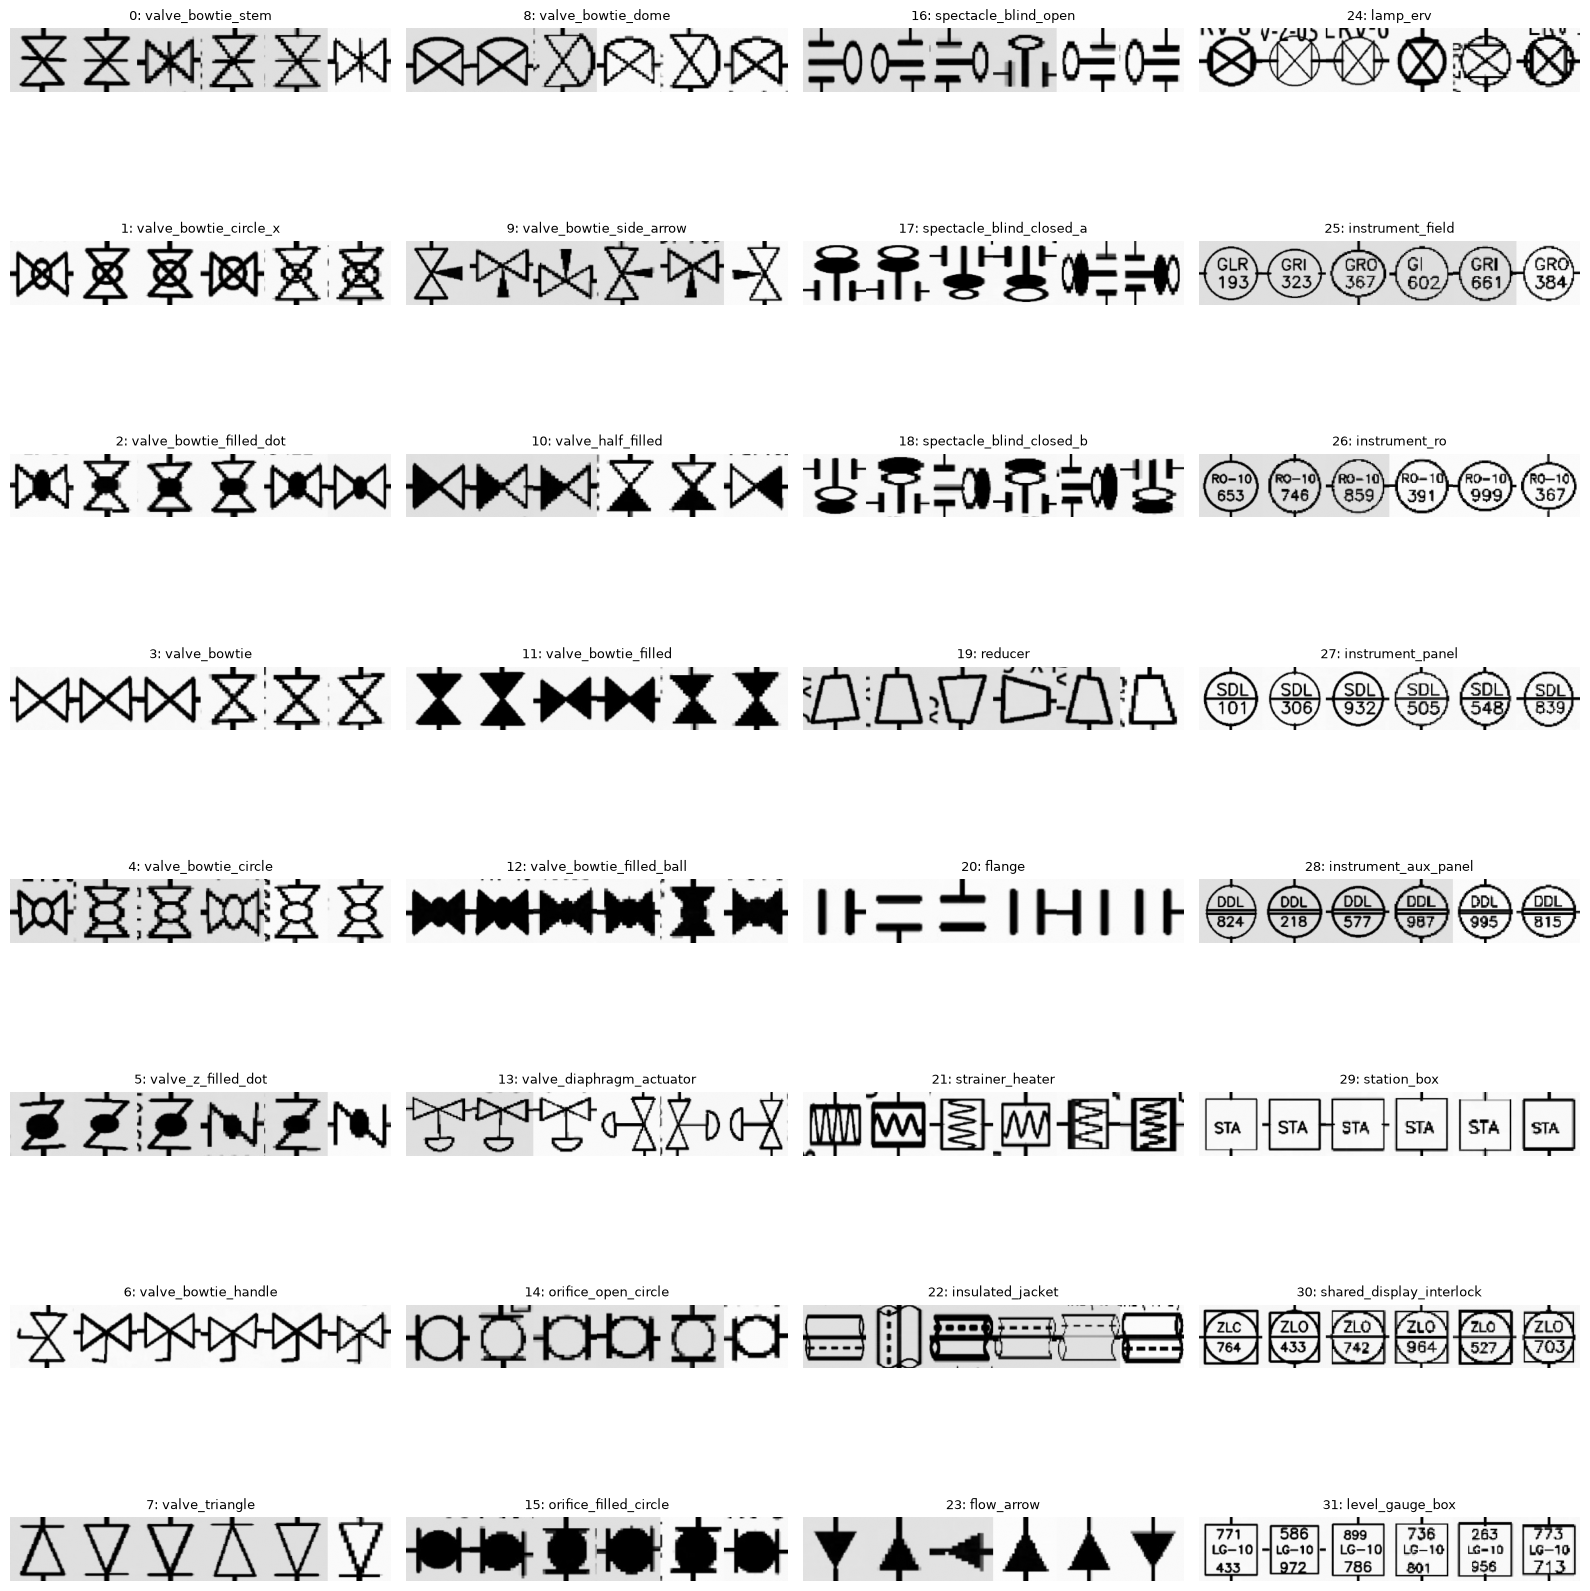

In [4]:
# Montage of a few examples per class
def class_montage(n_per=6, size=96, n_sheets=12):
    ex = defaultdict(list)
    for lp in sorted((DS / "labels/train").glob("*.txt"))[:n_sheets]:
        im = cv2.imread(str(DS / "images/train" / (lp.stem + ".jpg")), cv2.IMREAD_GRAYSCALE)
        b, l = read_yolo(lp, im.shape[1], im.shape[0])
        for (x1, y1, x2, y2), c in zip(b.astype(int), l):
            if len(ex[c]) < n_per:
                ex[c].append(cv2.resize(im[max(0, y1-6):y2+6, max(0, x1-6):x2+6], (size, size)))
    fig, axes = plt.subplots(8, 4, figsize=(16, 18))
    for c, ax in enumerate(axes.T.flatten()):
        row = ex[c] + [np.full((size, size), 255, np.uint8)] * (n_per - len(ex[c]))
        ax.imshow(np.hstack(row), cmap="gray"); ax.set_title(f"{c}: {CLASS_NAMES[c]}", fontsize=9); ax.axis("off")
    plt.tight_layout(); plt.show()
class_montage()

## 2a. Real-world P&IDs from Zenodo → HF/YOLO layout
The Zenodo archive is 6.7 GB; only `PID_Dataset/0__raw_data` (sheets + YOLO labels) is extracted. It also ships the authors'
Siamese-network code and weights, which we don't need. Conversion:
* `train` (72 sheets) → `train`, `test` (20 sheets) → `val`; files are prefixed `z` to avoid name clashes with the synthetic set.
* **Scale normalisation**: real drawings come at very different resolutions (median symbol size 22–950 px). Each sheet is
  resized so its median symbol side is `cfg.target_symbol_px` (the synthetic median), clamped to ×[0.5, 4].
  YOLO coordinates are normalised, so the label files stay valid unchanged.
* Class id `0` (`Symbol`) → `32` (`symbol_unspecified`), and `classes.txt` lists all 33 names, so the folder is a drop-in sibling
  of `DigitizePID_Dataset`.

In [5]:
import zipfile, urllib.request, shutil

def download_zenodo():
    zpath = cfg.zenodo_raw / "PID_Dataset.zip"
    raw = cfg.zenodo_raw / "PID_Dataset" / "0__raw_data"
    if raw.exists(): return raw
    cfg.zenodo_raw.mkdir(parents=True, exist_ok=True)
    if not zpath.exists():
        print("downloading Zenodo PID_Dataset.zip (6.7 GB) ...")
        tmp = zpath.with_suffix(".part")
        with urllib.request.urlopen(cfg.zenodo_url) as r, open(tmp, "wb") as f:
            shutil.copyfileobj(r, f, length=1 << 24)
        tmp.rename(zpath)
    with zipfile.ZipFile(zpath) as z:
        z.extractall(cfg.zenodo_raw, members=[m for m in z.namelist() if m.startswith("PID_Dataset/0__raw_data/")])
    return raw

def convert_zenodo():
    out = cfg.zenodo_dir / "ZenodoPID_Dataset"
    if (out / "classes.txt").exists(): return out
    raw = download_zenodo()
    stats = []
    for src_split, dst_split in (("train", "train"), ("test", "val")):
        (out / "images" / dst_split).mkdir(parents=True, exist_ok=True); (out / "labels" / dst_split).mkdir(parents=True, exist_ok=True)
        for ip in sorted((raw / "sheets" / src_split).glob("*.jpg")):
            lines = [l.split() for l in open(raw / "labels" / src_split / (ip.stem + ".txt")) if len(l.split()) == 5]
            im = cv2.imread(str(ip), cv2.IMREAD_GRAYSCALE); H, W = im.shape
            yolo = np.array([[float(v) for v in l[1:]] for l in lines], np.float32).reshape(-1, 4)
            med = np.median(np.maximum(yolo[:, 2] * W, yolo[:, 3] * H)) if len(yolo) else cfg.target_symbol_px
            f = float(np.clip(cfg.target_symbol_px / med, 0.5, 4.0))
            im = cv2.resize(im, (round(W * f), round(H * f)), interpolation=cv2.INTER_CUBIC if f > 1 else cv2.INTER_AREA)
            cv2.imwrite(str(out / "images" / dst_split / f"z{ip.stem}.jpg"), im, [cv2.IMWRITE_JPEG_QUALITY, 95])
            with open(out / "labels" / dst_split / f"z{ip.stem}.txt", "w") as fo:
                for x, y, w, h in yolo: fo.write(f"{UNSPECIFIED} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
            stats.append((dst_split, ip.name, W, H, f, len(yolo)))
    (out / "classes.txt").write_text("\n".join(LABEL_NAMES) + "\n")
    json.dump(stats, open(out / "conversion_log.json", "w"), indent=0)
    return out

ZDS = convert_zenodo()
_log = json.load(open(ZDS / "conversion_log.json"))
print(f"Zenodo converted: {sum(r[0]=='train' for r in _log)} train / {sum(r[0]=='val' for r in _log)} val sheets, "
      f"{sum(r[5] for r in _log)} boxes, rescale factors {min(r[4] for r in _log):.2f}..{max(r[4] for r in _log):.2f}")

Zenodo converted: 72 train / 20 val sheets, 4302 boxes, rescale factors 0.50..3.27


## 2b. Pre-processing (both datasets)
Each sheet is converted once to a grayscale, `input_scale`-resized `uint8` `.npy` file. Training reads **random crops
through `np.load(mmap_mode="r")`**, so every epoch sees new patch positions and scales instead of a fixed set of pre-cut
tiles, and only the needed rows are read from disk. Every index entry records its `source` (`digitize` or `zenodo`).

digitize : 400 train / 100 val sheets, 59498 symbols
zenodo   : 72 train / 20 val sheets, 4302 symbols
index built in 0s


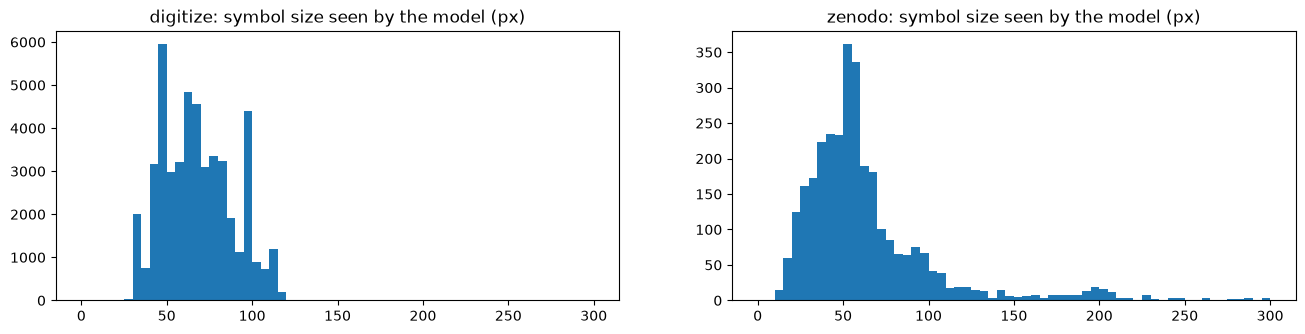

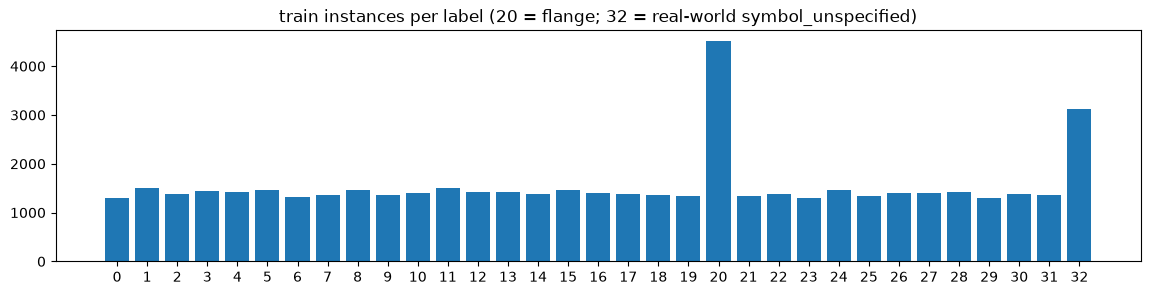

In [6]:
SOURCES = {"digitize": DS, "zenodo": ZDS}

def _prep_one(args):
    source, split, img_path, lbl_path, out_npy, scale = args
    im = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    H, W = im.shape
    if not Path(out_npy).exists():
        small = cv2.resize(im, (round(W*scale), round(H*scale)), interpolation=cv2.INTER_AREA)
        np.save(out_npy, small)
    boxes, labels = read_yolo(lbl_path, W, H)
    return dict(source=source, split=split, name=Path(img_path).name, img_path=img_path, npy=out_npy, W=W, H=H,
                boxes=boxes.tolist(), labels=labels.tolist())

def build_index(scale=cfg.input_scale):
    idx_file = cfg.cache_dir / f"index_s{scale}_{'+'.join(SOURCES)}.json"
    if idx_file.exists():
        return json.load(open(idx_file))
    (cfg.cache_dir / f"sheets_s{scale}").mkdir(parents=True, exist_ok=True)
    jobs = []
    for source, root in SOURCES.items():
        for split in ("train", "val"):
            for ip in sorted((root / "images" / split).glob("*.jpg"), key=lambda p: int(re.sub(r"\D", "", p.stem) or 0)):
                jobs.append((source, split, str(ip), str(root / "labels" / split / (ip.stem + ".txt")),
                             str(cfg.cache_dir / f"sheets_s{scale}" / f"{split}_{ip.stem}.npy"), scale))
    with Pool(min(16, os.cpu_count())) as pool:
        index = pool.map(_prep_one, jobs, chunksize=4)
    json.dump(index, open(idx_file, "w"))
    return index

t0 = time.time()
INDEX = build_index()
TRAIN = [s for s in INDEX if s["split"] == "train"]
VAL = [s for s in INDEX if s["split"] == "val"]
VAL_D = [s for s in VAL if s["source"] == "digitize"]     # synthetic, 32 classes
VAL_Z = [s for s in VAL if s["source"] == "zenodo"]       # real-world, class-agnostic
for src in SOURCES:
    tr = [s for s in TRAIN if s["source"] == src]; va = [s for s in VAL if s["source"] == src]
    print(f"{src:9s}: {len(tr)} train / {len(va)} val sheets, {sum(len(s['labels']) for s in tr + va)} symbols")
print(f"index built in {time.time()-t0:.0f}s")

fig, ax = plt.subplots(1, 2, figsize=(16, 3.5))
for src, a in zip(SOURCES, ax):
    b = np.concatenate([np.array(s["boxes"]).reshape(-1, 4) for s in TRAIN if s["source"] == src])
    a.hist(np.maximum(b[:, 2] - b[:, 0], b[:, 3] - b[:, 1]) * cfg.input_scale, bins=60, range=(0, 300))
    a.set_title(f"{src}: symbol size seen by the model (px)")
plt.show()
cnt = Counter(l for s in TRAIN for l in s["labels"])
plt.figure(figsize=(14, 3)); plt.bar(range(33), [cnt[i] for i in range(33)]); plt.xticks(range(33))
plt.title("train instances per label (20 = flange; 32 = real-world symbol_unspecified)"); plt.show()

## 3. Extra labels from Claude Sonnet 5.5 (tag names + pipe connections)

The HF dataset has symbol boxes only. The paper's relation head needs **edges**, and the final JSON needs **tag names**.
We get both with **set-of-marks prompting**: each symbol box is drawn on a native-resolution crop together with a numeric ID,
and Claude returns, as JSON constrained by a schema, (a) the tag text that belongs to each ID and (b) which IDs are joined by
a pipe/signal line. Crops (2048² native px, 512 px overlap) keep the text legible; results are merged across crops by voting.

* The same function runs at inference on *detected* boxes (§8) to refine tags/connections.
* Responses are cached on disk (`data/cache/claude/`), so re-running is free and interrupted runs resume.
* Cost control: `cfg.claude_label_train_sheets` / `cfg.claude_label_val_sheets`. Token usage and estimated cost are printed
  (Sonnet 5.5: $2 / $10 per M input/output tokens). Roughly 15 crops per sheet.
* Server-side refusal fallback (`fallbacks="default"`) is enabled so a rare safety decline is retried on another model automatically.
* Credentials: `ANTHROPIC_API_KEY` env var (or an `ant auth login` profile). Without credentials this section is skipped and
  the relation head is simply not trained (the detector is unaffected).

Note: these are **pseudo-labels**. Edge metrics computed against them measure agreement with Claude, not true ground truth.
For true line/text ground truth, the original Digitize-PID release (Google Drive link in the HF card) also has line and word annotations.

In [7]:
import anthropic

CLAUDE_DIR = cfg.cache_dir / "claude"; CLAUDE_DIR.mkdir(parents=True, exist_ok=True)
USAGE = Counter()

def claude_available():
    try:
        anthropic.Anthropic().models.retrieve(cfg.claude_model)
        return True
    except Exception as e:
        print("Claude not available ->", type(e).__name__, str(e)[:200])
        return False

SOM_SCHEMA = {
    "type": "object",
    "properties": {
        "symbols": {"type": "array", "items": {
            "type": "object",
            "properties": {"id": {"type": "integer"},
                           "tag": {"type": "string", "description": "tag text for this symbol, '' if none is visible"}},
            "required": ["id", "tag"], "additionalProperties": False}},
        "connections": {"type": "array", "items": {
            "type": "object",
            "properties": {"a": {"type": "integer"}, "b": {"type": "integer"},
                           "style": {"type": "string", "enum": ["solid", "dashed"]}},
            "required": ["a", "b", "style"], "additionalProperties": False}},
    },
    "required": ["symbols", "connections"], "additionalProperties": False,
}

SOM_PROMPT = """This image is a crop of a Piping & Instrumentation Diagram (P&ID). Every detected symbol is outlined with a red box and labelled with a red numeric ID on a white background.

Symbols in this crop (ID: symbol type):
{legend}

Tasks:
1. For each ID, give the equipment tag text that belongs to that symbol: either text written inside the symbol (instrument bubbles like "GLR / 193" -> "GLR-193", "SDL / 101" -> "SDL-101") or the tag label printed right next to it (e.g. "WX-71994", "CS-08", "ERV-8-20"; labels may be rotated 90 degrees). Do not use pipe line numbers such as 4"-JO-9505 or pipe sizes like 12" as tags. Use '' if no tag belongs to the symbol.
2. List the pipe/signal connections between IDs: two IDs are connected when a drawn line path (following bends and T-junctions, solid or dashed) runs from one symbol to the other without passing through another numbered symbol. Report each pair once. Only use IDs listed above; ignore lines that leave the crop.

Answer with JSON only."""

def _draw_som(gray_crop, boxes_local, ids, scale_out):
    """Draw numbered boxes on a crop, then resize by scale_out. Returns RGB uint8."""
    img = cv2.cvtColor(gray_crop, cv2.COLOR_GRAY2BGR)
    img = cv2.resize(img, None, fx=scale_out, fy=scale_out, interpolation=cv2.INTER_AREA)
    for (x1, y1, x2, y2), i in zip((boxes_local * scale_out).astype(int), ids):
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
        txt = str(i); (tw, th), _ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
        tx, ty = x1, max(th + 2, y1 - 3)
        cv2.rectangle(img, (tx, ty - th - 2), (tx + tw + 2, ty + 2), (255, 255, 255), -1)
        cv2.putText(img, txt, (tx + 1, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255), 2)
    return img

def som_windows(W, H, tile=None, overlap=None):
    tile = tile or cfg.claude_tile; stride = tile - (overlap or cfg.claude_overlap)
    xs = list(range(0, max(W - tile, 0) + 1, stride)); ys = list(range(0, max(H - tile, 0) + 1, stride))
    if xs[-1] + tile < W: xs.append(W - tile)
    if ys[-1] + tile < H: ys.append(H - tile)
    return [(x, y, min(x + tile, W), min(y + tile, H)) for y in ys for x in xs]

def claude_som_call(png_bytes, legend):
    client = anthropic.Anthropic(max_retries=4)
    resp = client.beta.messages.create(
        model=cfg.claude_model,
        max_tokens=16000,
        betas=["server-side-fallback-2026-07-01"],
        fallbacks="default",
        output_config={"effort": cfg.claude_effort, "format": {"type": "json_schema", "schema": SOM_SCHEMA}},
        messages=[{"role": "user", "content": [
            {"type": "image", "source": {"type": "base64", "media_type": "image/png",
                                         "data": base64.standard_b64encode(png_bytes).decode()}},
            {"type": "text", "text": SOM_PROMPT.format(legend=legend)},
        ]}],
    )
    USAGE["input"] += resp.usage.input_tokens; USAGE["output"] += resp.usage.output_tokens; USAGE["calls"] += 1
    if resp.stop_reason in ("refusal", "max_tokens"):
        raise RuntimeError(f"stop_reason={resp.stop_reason}")
    text = next(b.text for b in resp.content if b.type == "text")
    return json.loads(text)

def claude_label_sheet(img_path, boxes, labels, cache_key, min_box_frac=0.6):
    """Set-of-marks labelling of one sheet. boxes: (N,4) native xyxy. Returns {'tags': {id: tag}, 'edges': [(a,b,style,votes)]}."""
    out_file = CLAUDE_DIR / f"{cache_key}.json"
    if out_file.exists():
        return json.load(open(out_file))
    im = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE); H, W = im.shape
    boxes = np.asarray(boxes, np.float32).reshape(-1, 4)
    jobs = []
    for (x0, y0, x1, y1) in som_windows(W, H):
        ix1 = np.clip(boxes[:, 0], x0, x1); iy1 = np.clip(boxes[:, 1], y0, y1)
        ix2 = np.clip(boxes[:, 2], x0, x1); iy2 = np.clip(boxes[:, 3], y0, y1)
        frac = (ix2 - ix1) * (iy2 - iy1) / np.maximum((boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]), 1)
        sel = np.where(frac >= min_box_frac)[0]
        if len(sel) == 0: continue
        local = boxes[sel] - np.array([x0, y0, x0, y0], np.float32)
        img = _draw_som(im[y0:y1, x0:x1], local, sel, scale_out=min(1.0, 1568 / max(x1 - x0, y1 - y0)))
        png = cv2.imencode(".png", img)[1].tobytes()
        legend = "\n".join(f"{i}: {LABEL_NAMES[labels[i]]}" for i in sel)
        jobs.append((png, legend, set(sel.tolist())))
    tag_votes, edge_votes = defaultdict(Counter), Counter()
    with ThreadPoolExecutor(cfg.claude_workers) as ex:
        futs = {ex.submit(claude_som_call, png, legend): ids for png, legend, ids in jobs}
        for f in as_completed(futs):
            ids = futs[f]
            try:
                r = f.result()
            except Exception as e:
                print("  crop failed:", type(e).__name__, str(e)[:120]); continue
            for s in r["symbols"]:
                if s["id"] in ids and s["tag"].strip():
                    tag_votes[s["id"]][s["tag"].strip().upper()] += 1
            for c in r["connections"]:
                a, b = int(c["a"]), int(c["b"])
                if a != b and a in ids and b in ids:
                    edge_votes[(min(a, b), max(a, b), c["style"])] += 1
    res = {"tags": {str(i): v.most_common(1)[0][0] for i, v in tag_votes.items()},
           "edges": [[a, b, st, n] for (a, b, st), n in edge_votes.items()]}
    json.dump(res, open(out_file, "w"))
    return res

def usage_report():
    cost = USAGE["input"] / 1e6 * 2 + USAGE["output"] / 1e6 * 10
    print(f"Claude calls={USAGE['calls']} in={USAGE['input']:,} out={USAGE['output']:,} tokens  ~${cost:.2f}")

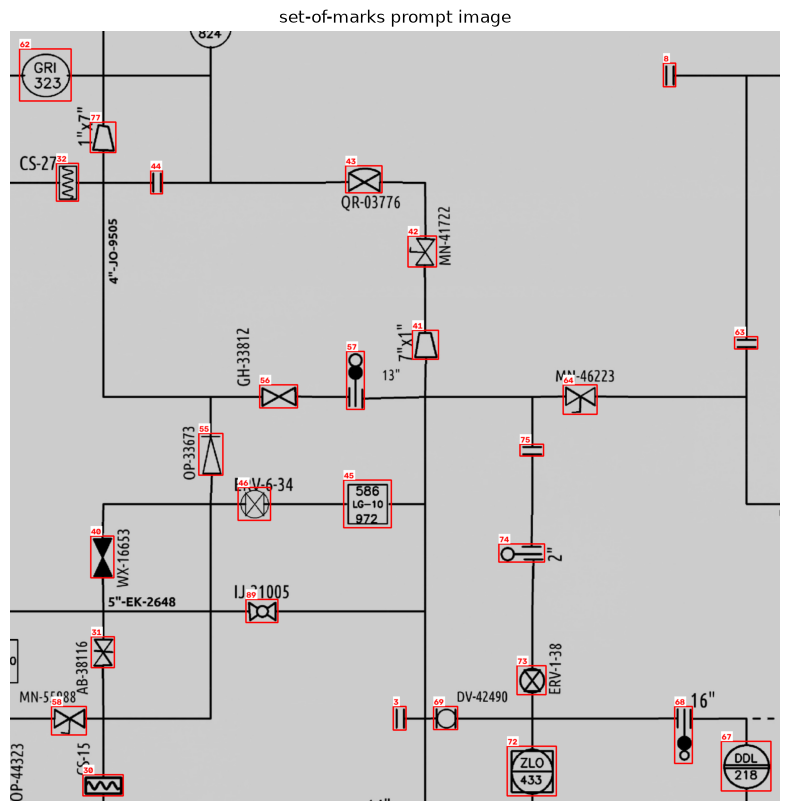

In [8]:
# Preview of a set-of-marks crop (no API call)
_s = TRAIN[0]
_im = cv2.imread(_s["img_path"], cv2.IMREAD_GRAYSCALE)
_b = np.array(_s["boxes"], np.float32); _win = som_windows(_s["W"], _s["H"])[6]
_in = np.where((_b[:, 0] >= _win[0]) & (_b[:, 2] <= _win[2]) & (_b[:, 1] >= _win[1]) & (_b[:, 3] <= _win[3]))[0]
_prev = _draw_som(_im[_win[1]:_win[3], _win[0]:_win[2]], _b[_in] - np.array(_win[:2] * 2, np.float32), _in, 1568 / cfg.claude_tile)
plt.figure(figsize=(10, 10)); plt.imshow(_prev[..., ::-1]); plt.axis("off"); plt.title("set-of-marks prompt image"); plt.show()

In [9]:
CLAUDE_OK = claude_available()
CLAUDE_LABELS = {}   # sheet key -> {'tags':..., 'edges':...}
if CLAUDE_OK:
    todo = TRAIN[:cfg.claude_label_train_sheets] + VAL[:cfg.claude_label_val_sheets]
    print(f"labelling {len(todo)} sheets with {cfg.claude_model} ...")
    for k, s in enumerate(todo):
        key = f"gt_{s['split']}_{Path(s['name']).stem}"
        CLAUDE_LABELS[(s["split"], s["name"])] = claude_label_sheet(s["img_path"], s["boxes"], s["labels"], key)
        if k % 10 == 0: print(f"  {k+1}/{len(todo)}", end=" "); usage_report()
    usage_report()
else:
    # still pick up anything cached from a previous run
    for s in INDEX:
        f = CLAUDE_DIR / f"gt_{s['split']}_{Path(s['name']).stem}.json"
        if f.exists(): CLAUDE_LABELS[(s["split"], s["name"])] = json.load(open(f))
print("sheets with Claude labels:", len(CLAUDE_LABELS))

def sheet_edges(s):
    """Undirected edges (i<j) between GT symbol indices of a sheet, or None if the sheet is unlabelled."""
    lab = CLAUDE_LABELS.get((s["split"], s["name"]))
    if lab is None: return None
    return np.array(sorted({(a, b) for a, b, _, _ in lab["edges"]}), np.int64).reshape(-1, 2)

Claude not available -> TypeError "Could not resolve authentication method. Expected one of api_key, auth_token, or credentials to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"
sheets with Claude labels: 0


## 4. Patch datasets
* **Train**: random crops with scale jitter (0.8–1.25×), biased towards symbols (80 % of crops centred on a random symbol),
  random 90° rotations and flips, brightness/contrast, blur and noise. Boxes cut by the crop border are kept if
  ≥ `min_visible` of their area is inside (the paper notes truncated symbols as a main error source).
* **Mixed sampling**: `cfg.zenodo_sample_frac` of the crops come from the 72 real sheets (≈30 %), the rest from the 400 synthetic
  ones, which oversamples the real data much as the paper does (3× augmentation of real sheets).
* Each target carries the sheet-level symbol indices, so Claude's sheet-level edges become patch-level edge targets for the relation head.
* **Val**: deterministic grid of patches over the validation sheets (patch-level mAP, as "Patched" in the paper's Table III).

In [10]:
IMG_MEAN, IMG_STD = 0.449 * 255, 0.226 * 255   # ImageNet grey statistics

def boxes_for_crop(boxes, x0, y0, cw, ch, min_visible):
    """boxes: (N,4) xyxy in sheet pixel coords -> clipped local boxes + kept indices."""
    if len(boxes) == 0: return np.zeros((0, 4), np.float32), np.zeros(0, np.int64)
    b = boxes - np.array([x0, y0, x0, y0], np.float32)
    area = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    c = np.stack([b[:, 0].clip(0, cw), b[:, 1].clip(0, ch), b[:, 2].clip(0, cw), b[:, 3].clip(0, ch)], 1)
    vis = (c[:, 2] - c[:, 0]) * (c[:, 3] - c[:, 1]) / np.maximum(area, 1e-6)
    keep = np.where(vis >= min_visible)[0]
    return c[keep], keep

def read_crop(arr, x0, y0, cw, ch):
    """Crop; areas outside the sheet are filled with the sheet's paper colour (small real sheets can be < 1 tile)."""
    H, W = arr.shape
    xa, ya, xb, yb = max(x0, 0), max(y0, 0), min(x0 + cw, W), min(y0 + ch, H)
    crop = np.asarray(arr[ya:yb, xa:xb])
    if crop.shape != (ch, cw):
        crop = cv2.copyMakeBorder(crop, ya - y0, y0 + ch - yb, xa - x0, x0 + cw - xb, cv2.BORDER_CONSTANT,
                                  value=int(np.median(crop)) if crop.size else 255)
    return crop

def rand_origin(L, cs):
    """Random crop origin along one axis; allows negative origins when the sheet is smaller than the crop."""
    return random.randint(0, L - cs) if L >= cs else random.randint(L - cs, 0)

class SheetMixin:
    def __init__(self, sheets):
        self.sheets = sheets
        self.boxes = [np.array(s["boxes"], np.float32).reshape(-1, 4) * cfg.input_scale for s in sheets]
        self.labels = [np.array(s["labels"], np.int64) for s in sheets]
        self.edges = [sheet_edges(s) for s in sheets]
        self._arr = {}
    def arr(self, i):
        if i not in self._arr: self._arr[i] = np.load(self.sheets[i]["npy"], mmap_mode="r")
        return self._arr[i]
    def make_target(self, i, local_boxes, keep, size):
        S = float(size)
        cxcywh = np.stack([(local_boxes[:, 0] + local_boxes[:, 2]) / 2, (local_boxes[:, 1] + local_boxes[:, 3]) / 2,
                           local_boxes[:, 2] - local_boxes[:, 0], local_boxes[:, 3] - local_boxes[:, 1]], 1) / S
        t = {"boxes": torch.from_numpy(cxcywh.astype(np.float32)).reshape(-1, 4), "labels": torch.from_numpy(self.labels[i][keep]),
             "gt_idx": torch.from_numpy(keep), "sheet": i, "has_edges": self.edges[i] is not None}
        e = np.zeros((0, 2), np.int64)
        if self.edges[i] is not None and len(self.edges[i]) and len(keep):
            pos = {g: k for k, g in enumerate(keep.tolist())}
            e = np.array([(pos[a], pos[b]) for a, b in self.edges[i] if a in pos and b in pos], np.int64).reshape(-1, 2)
        t["edges"] = torch.from_numpy(e)
        return t

def to_tensor(gray):
    return torch.from_numpy((gray.astype(np.float32) - IMG_MEAN) / IMG_STD)[None]

class TrainPatches(SheetMixin, Dataset):
    def __init__(self, sheets, length):
        super().__init__(sheets); self.length = length
        zen = np.array([s.get("source") == "zenodo" for s in sheets])
        frac = cfg.zenodo_sample_frac if zen.any() and (~zen).any() else float(zen.mean())
        self.p = np.where(zen, frac / max(zen.sum(), 1), (1 - frac) / max((~zen).sum(), 1))
        self.p /= self.p.sum()
    def __len__(self): return self.length
    def __getitem__(self, _):
        T = cfg.tile
        i = int(np.random.choice(len(self.sheets), p=self.p)); arr = self.arr(i); H, W = arr.shape
        cs = int(T / random.uniform(0.8, 1.25))                      # scale jitter
        if random.random() < 0.8 and len(self.boxes[i]):
            b = self.boxes[i][random.randrange(len(self.boxes[i]))]
            cx, cy = (b[0] + b[2]) / 2 + random.uniform(-0.4, 0.4) * cs, (b[1] + b[3]) / 2 + random.uniform(-0.4, 0.4) * cs
            x0 = int(np.clip(cx - cs / 2, min(0, W - cs), max(0, W - cs)))
            y0 = int(np.clip(cy - cs / 2, min(0, H - cs), max(0, H - cs)))
        else:
            x0, y0 = rand_origin(W, cs), rand_origin(H, cs)
        crop = read_crop(arr, x0, y0, cs, cs)
        lb, keep = boxes_for_crop(self.boxes[i], x0, y0, cs, cs, cfg.min_visible)
        crop = cv2.resize(crop, (T, T), interpolation=cv2.INTER_AREA if cs > T else cv2.INTER_LINEAR)
        lb = lb * (T / cs)
        crop, lb = self.augment(crop, lb, T)
        return to_tensor(crop), self.make_target(i, lb, keep, T)

    @staticmethod
    def augment(img, b, T):
        k = random.randrange(4)                                     # rot90 k times counter-clockwise
        for _ in range(k):
            img = np.ascontiguousarray(np.rot90(img))
            b = np.stack([b[:, 1], T - b[:, 2], b[:, 3], T - b[:, 0]], 1) if len(b) else b
        if random.random() < 0.5:
            img = img[:, ::-1]; b = np.stack([T - b[:, 2], b[:, 1], T - b[:, 0], b[:, 3]], 1) if len(b) else b
        img = img.astype(np.float32)
        img = (img - 128) * random.uniform(0.7, 1.3) + 128 + random.uniform(-40, 40)   # contrast / brightness
        if random.random() < 0.2: img = cv2.GaussianBlur(img, (0, 0), random.uniform(0.3, 1.2))
        if random.random() < 0.2: img = img + np.random.randn(*img.shape).astype(np.float32) * random.uniform(2, 12)
        return np.clip(img, 0, 255).astype(np.uint8), b.astype(np.float32)

def grid_positions(W, H, T, stride):
    xs = list(range(0, max(W - T, 0) + 1, stride)); ys = list(range(0, max(H - T, 0) + 1, stride))
    if xs[-1] + T < W: xs.append(W - T)
    if ys[-1] + T < H: ys.append(H - T)
    return [(x, y) for y in ys for x in xs]

class ValPatches(SheetMixin, Dataset):
    def __init__(self, sheets, stride=cfg.tile):
        super().__init__(sheets)
        self.items = []
        for i, s in enumerate(sheets):
            H, W = np.load(s["npy"], mmap_mode="r").shape
            self.items += [(i, x, y) for x, y in grid_positions(W, H, cfg.tile, stride)]
    def __len__(self): return len(self.items)
    def __getitem__(self, k):
        i, x0, y0 = self.items[k]; T = cfg.tile
        crop = read_crop(self.arr(i), x0, y0, T, T)
        lb, keep = boxes_for_crop(self.boxes[i], x0, y0, T, T, cfg.min_visible)
        return to_tensor(crop), self.make_target(i, lb, keep, T)

def collate(batch):
    return torch.stack([b[0] for b in batch]), [b[1] for b in batch]

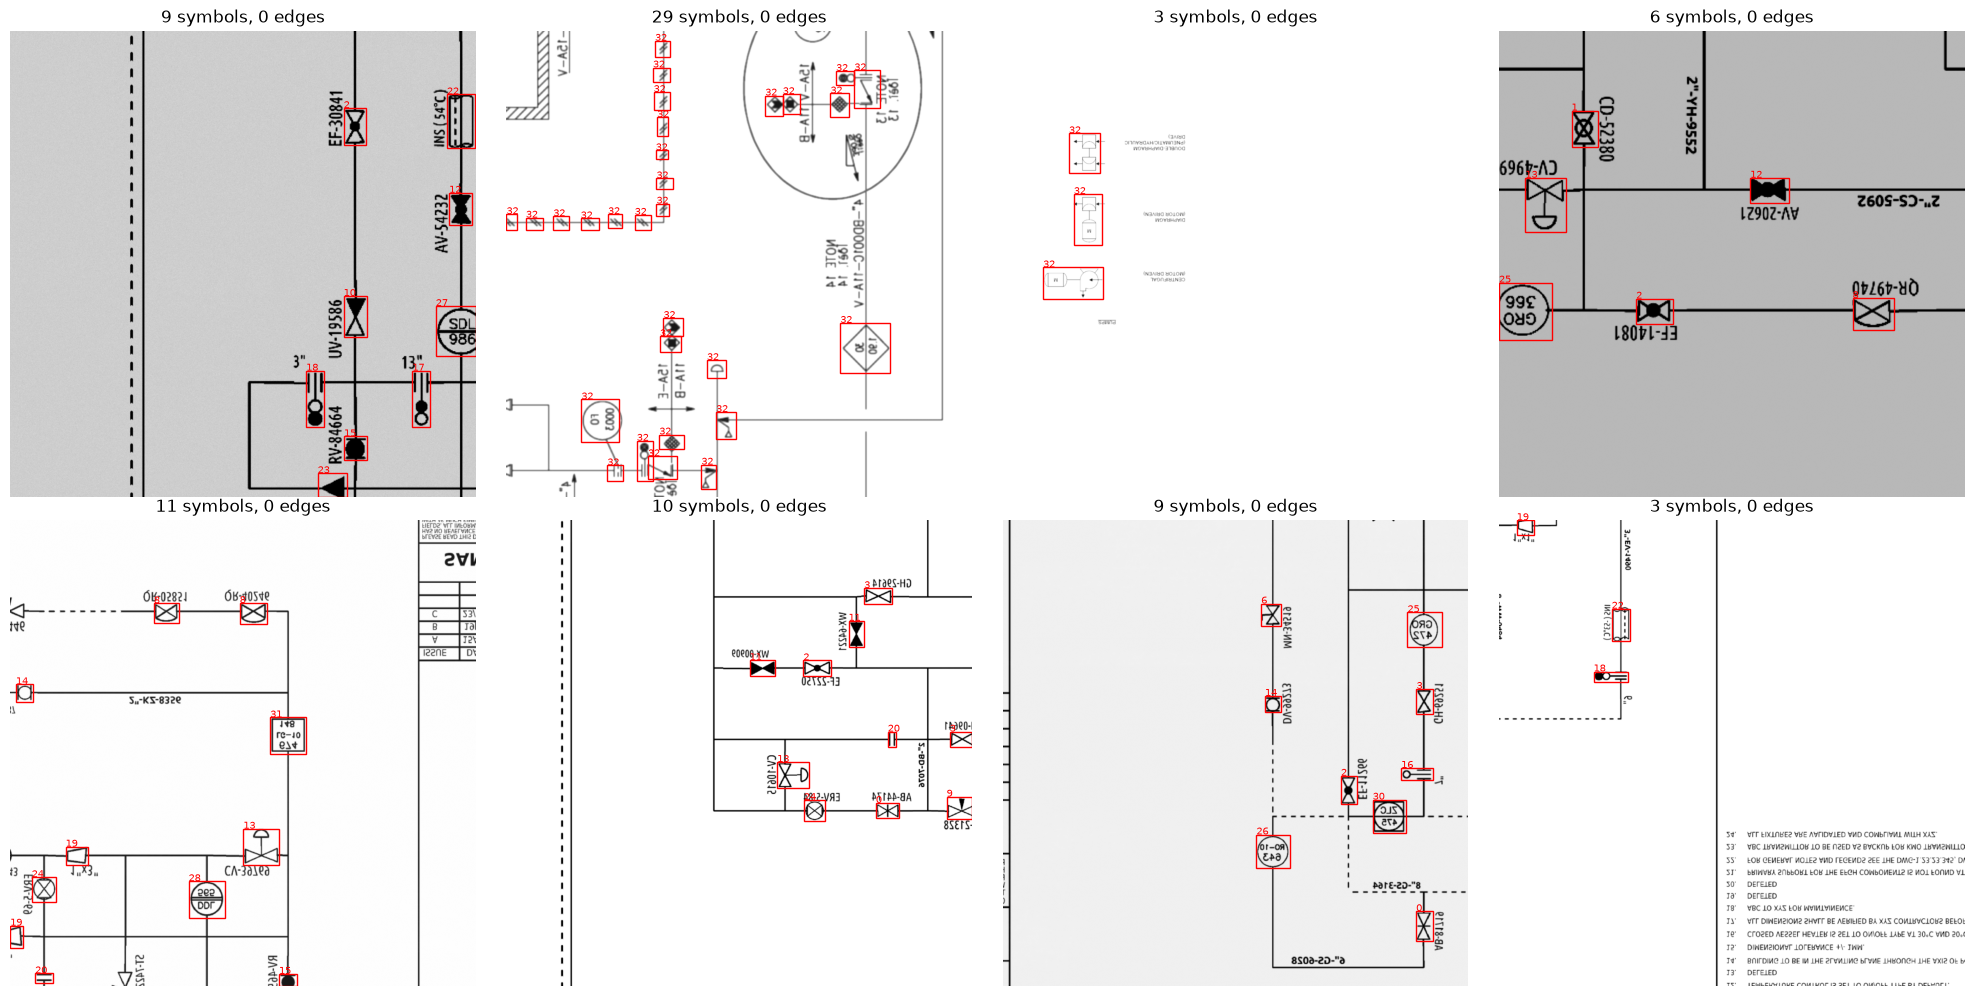

In [11]:
# Visual sanity check of augmented training patches
_ds = TrainPatches(TRAIN, 8)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax in axes.flat:
    img, t = _ds[0]
    ax.imshow(img[0].numpy() * IMG_STD + IMG_MEAN, cmap="gray", vmin=0, vmax=255)
    for (cx, cy, w, h), l in zip(t["boxes"].numpy() * cfg.tile, t["labels"].numpy()):
        ax.add_patch(plt.Rectangle((cx - w/2, cy - h/2), w, h, fill=False, ec="r", lw=1))
        ax.text(cx - w/2, cy - h/2, str(l), color="r", fontsize=7)
    ax.set_title(f"{len(t['labels'])} symbols, {len(t['edges'])} edges"); ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Model: PIDFormer (Relationformer + DINO-style improvements + contrastive head)

```
patch ─► ResNet (frozen BN) ─► C3,C4,C5 ─► 1×1 proj ─► Encoder: "hybrid" (default) = self-attention on C5 + CNN FPN/PAN fusion (RT-DETR)
                                                           │          "deformable"     = 6-layer multi-scale deformable encoder (paper)
                        two-stage proposals ◄──────────────┤ (top-K encoder tokens → anchor boxes, mixed query selection)
                                                           ▼
  [ CDN queries | 300 object queries | [rln] token ] ─► Deformable decoder (6 layers, iterative box refinement, look-forward-twice)
       │                  │                   │
  denoising loss     class / box heads     relation MLP( o_i , o_j , rln ) → edge logit       (Relationformer)
                     projection head → 128-d embedding → SupCon loss                          (contrastive)
```
Multi-scale deformable attention is written in pure PyTorch (`grid_sample`), so no custom CUDA build is needed.

**Why a hybrid encoder by default?** The paper's deformable encoder runs deformable self-attention over all ~21k multi-scale
tokens of a 1024² patch. Its pure-PyTorch backward pass made one training step take ~4 s and used ~24 GB on a 4090. The
RT-DETR-style *efficient hybrid encoder* applies full self-attention only to the 32×32 stride-32 tokens (global context) and fuses
scales with a light CNN top-down/bottom-up path. It is about 10× cheaper with equal or better accuracy (RT-DETR, D-FINE, DEIM).
Set `cfg.encoder = "deformable"` to use the paper's encoder.

In [12]:
def inverse_sigmoid(x, eps=1e-5):
    x = x.clamp(0, 1)
    return torch.log(x.clamp(min=eps) / (1 - x).clamp(min=eps))

def box_cxcywh_to_xyxy(b):
    cx, cy, w, h = b.unbind(-1)
    return torch.stack([cx - w/2, cy - h/2, cx + w/2, cy + h/2], -1)

class MLP(nn.Module):
    def __init__(self, i, h, o, n):
        super().__init__()
        dims = [i] + [h] * (n - 1)
        self.layers = nn.ModuleList(nn.Linear(a, b) for a, b in zip(dims, dims[1:] + [o]))
    def forward(self, x):
        for k, l in enumerate(self.layers):
            x = l(x) if k == len(self.layers) - 1 else F.relu(l(x))
        return x

def ms_deform_attn_core(value, shapes, loc, attn):
    """value (B,S,nH,Dh); loc (B,Lq,nH,nL,nP,2) in [0,1]; attn (B,Lq,nH,nL,nP) -> (B,Lq,nH*Dh)"""
    B, S, nH, Dh = value.shape
    _, Lq, _, nL, nP, _ = loc.shape
    values = value.split([h * w for h, w in shapes], dim=1)
    grids = 2 * loc - 1
    samples = []
    for l, (h, w) in enumerate(shapes):
        v = values[l].flatten(2).transpose(1, 2).reshape(B * nH, Dh, h, w)
        g = grids[:, :, :, l].transpose(1, 2).flatten(0, 1)                   # (B*nH, Lq, nP, 2)
        samples.append(F.grid_sample(v, g.to(v.dtype), mode="bilinear", padding_mode="zeros", align_corners=False))
    a = attn.transpose(1, 2).reshape(B * nH, 1, Lq, nL * nP)
    out = (torch.stack(samples, dim=-2).flatten(-2) * a.to(samples[0].dtype)).sum(-1)   # (B*nH, Dh, Lq)
    return out.view(B, nH * Dh, Lq).transpose(1, 2)

class MSDeformAttn(nn.Module):
    def __init__(self, d, nL, nH, nP):
        super().__init__()
        self.nL, self.nH, self.nP = nL, nH, nP
        self.sampling_offsets = nn.Linear(d, nH * nL * nP * 2)
        self.attention_weights = nn.Linear(d, nH * nL * nP)
        self.value_proj = nn.Linear(d, d); self.output_proj = nn.Linear(d, d)
        nn.init.zeros_(self.sampling_offsets.weight)
        th = torch.arange(nH, dtype=torch.float32) * (2 * math.pi / nH)
        grid = torch.stack([th.cos(), th.sin()], -1)
        grid = (grid / grid.abs().max(-1, keepdim=True)[0]).view(nH, 1, 1, 2).repeat(1, nL, nP, 1)
        for i in range(nP): grid[:, :, i] *= i + 1
        with torch.no_grad(): self.sampling_offsets.bias.copy_(grid.view(-1))
        nn.init.zeros_(self.attention_weights.weight); nn.init.zeros_(self.attention_weights.bias)
        for m in (self.value_proj, self.output_proj): nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, query, ref, value_in, shapes):
        B, Lq, _ = query.shape
        v = self.value_proj(value_in).view(B, value_in.shape[1], self.nH, -1)
        off = self.sampling_offsets(query).view(B, Lq, self.nH, self.nL, self.nP, 2)
        aw = self.attention_weights(query).view(B, Lq, self.nH, self.nL * self.nP).softmax(-1)
        aw = aw.view(B, Lq, self.nH, self.nL, self.nP)
        if ref.shape[-1] == 2:   # encoder: points
            norm = torch.tensor([[w, h] for h, w in shapes], device=query.device, dtype=off.dtype)
            loc = ref[:, :, None, :, None, :] + off / norm[None, None, None, :, None, :]
        else:                    # decoder: boxes (offsets scaled by box size)
            loc = ref[:, :, None, :, None, :2] + off / self.nP * ref[:, :, None, :, None, 2:] * 0.5
        return self.output_proj(ms_deform_attn_core(v, shapes, loc, aw))

class EncoderLayer(nn.Module):
    def __init__(self, d, ffn, nL, nH, nP):
        super().__init__()
        self.attn = MSDeformAttn(d, nL, nH, nP); self.n1 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(nn.Linear(d, ffn), nn.ReLU(inplace=True), nn.Linear(ffn, d)); self.n2 = nn.LayerNorm(d)
    def forward(self, src, pos, ref, shapes):
        src = self.n1(src + self.attn(src + pos, ref, src, shapes))
        return self.n2(src + self.ffn(src))

class ConvBN(nn.Sequential):
    def __init__(self, i, o, k=1, s=1):
        super().__init__(nn.Conv2d(i, o, k, s, k // 2, bias=False), nn.BatchNorm2d(o), nn.SiLU(inplace=True))

class CSPBlock(nn.Module):
    """RepC3-style cross-stage-partial fusion block (RT-DETR CCFM)."""
    def __init__(self, i, o, n=3):
        super().__init__()
        self.c1, self.c2 = ConvBN(i, o), ConvBN(i, o)
        self.m = nn.Sequential(*[ConvBN(o, o, 3) for _ in range(n)])
    def forward(self, x):
        return self.m(self.c1(x)) + self.c2(x)

class AIFILayer(nn.Module):
    """Transformer layer on the stride-32 tokens; positional encoding added to queries/keys only."""
    def __init__(self, d, nH, ffn):
        super().__init__()
        self.sa = nn.MultiheadAttention(d, nH, batch_first=True); self.n1 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(nn.Linear(d, ffn), nn.GELU(), nn.Linear(ffn, d)); self.n2 = nn.LayerNorm(d)
    def forward(self, x, pos):
        q = x + pos
        x = self.n1(x + self.sa(q, q, x, need_weights=False)[0])
        return self.n2(x + self.ffn(x))

class HybridEncoder(nn.Module):
    """RT-DETR efficient hybrid encoder: intra-scale attention (AIFI) on C5 + cross-scale CNN fusion (top-down + bottom-up)."""
    def __init__(self, d, nH, ffn, n_layers, n_levels):
        super().__init__()
        self.aifi = nn.ModuleList(AIFILayer(d, nH, ffn) for _ in range(n_layers))
        self.lateral = nn.ModuleList(ConvBN(d, d) for _ in range(n_levels - 1))
        self.fpn = nn.ModuleList(CSPBlock(2 * d, d) for _ in range(n_levels - 1))
        self.down = nn.ModuleList(ConvBN(d, d, 3, 2) for _ in range(n_levels - 1))
        self.pan = nn.ModuleList(CSPBlock(2 * d, d) for _ in range(n_levels - 1))
    def forward(self, feats, pos_top):
        B, d, h, w = feats[-1].shape
        t = feats[-1].flatten(2).transpose(1, 2)
        for layer in self.aifi: t = layer(t, pos_top)
        feats = list(feats[:-1]) + [t.transpose(1, 2).reshape(B, d, h, w)]
        inner = [feats[-1]]                                       # top-down (FPN)
        for k, lvl in enumerate(range(len(feats) - 1, 0, -1)):
            hi = self.lateral[k](inner[0]); inner[0] = hi
            up = F.interpolate(hi, size=feats[lvl - 1].shape[-2:], mode="nearest")
            inner.insert(0, self.fpn[k](torch.cat([up, feats[lvl - 1]], 1)))
        outs = [inner[0]]                                         # bottom-up (PAN)
        for k in range(len(feats) - 1):
            outs.append(self.pan[k](torch.cat([self.down[k](outs[-1]), inner[k + 1]], 1)))
        return outs

class DecoderLayer(nn.Module):
    def __init__(self, d, ffn, nL, nH, nP):
        super().__init__()
        self.sa = nn.MultiheadAttention(d, nH, batch_first=True); self.n1 = nn.LayerNorm(d)
        self.ca = MSDeformAttn(d, nL, nH, nP); self.n2 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(nn.Linear(d, ffn), nn.ReLU(inplace=True), nn.Linear(ffn, d)); self.n3 = nn.LayerNorm(d)
    def forward(self, tgt, qpos, ref, memory, shapes, attn_mask):
        q = tgt + qpos
        tgt = self.n1(tgt + self.sa(q, q, tgt, attn_mask=attn_mask, need_weights=False)[0])
        tgt = self.n2(tgt + self.ca(tgt + qpos, ref[:, :, None].expand(-1, -1, len(shapes), -1), memory, shapes))
        return self.n3(tgt + self.ffn(tgt))

def sine_embed(pos, num_feats=128, temp=10000):
    """pos (..., k) in [0,1] -> (..., k*num_feats) sine/cosine embedding (DINO style)."""
    dim_t = torch.arange(num_feats, device=pos.device, dtype=torch.float32)
    dim_t = temp ** (2 * (dim_t // 2) / num_feats)
    x = pos[..., None].float() * 2 * math.pi / dim_t
    x = torch.stack([x[..., 0::2].sin(), x[..., 1::2].cos()], -1).flatten(-2)
    return x.flatten(-2)

def freeze_bn(module):
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            f = FrozenBatchNorm2d(child.num_features, eps=child.eps)
            f.weight.copy_(child.weight.data); f.bias.copy_(child.bias.data)
            f.running_mean.copy_(child.running_mean); f.running_var.copy_(child.running_var)
            setattr(module, name, f)
        else:
            freeze_bn(child)
    return module

class PIDFormer(nn.Module):
    def __init__(self, c: Config, pretrained=True):
        super().__init__()
        self.c = c; d = c.d_model; C = c.num_classes; self.C = C
        self.backbone = freeze_bn(timm.create_model(c.backbone, pretrained=pretrained, features_only=True,
                                                    out_indices=tuple(range(5 - c.n_levels, 5))))
        for n, p in self.backbone.named_parameters():   # freeze stem + first stage (DETR convention)
            if n.startswith(("conv1", "bn1", "layer1", "stem", "stages.0", "stages_0")): p.requires_grad_(False)
        self.input_proj = nn.ModuleList(nn.Sequential(nn.Conv2d(ch, d, 1), nn.GroupNorm(32, d))
                                        for ch in self.backbone.feature_info.channels())
        self.level_embed = nn.Parameter(torch.randn(c.n_levels, d) * 0.02)
        if c.encoder == "hybrid":
            self.encoder = HybridEncoder(d, c.n_heads, c.ffn_dim, c.enc_layers, c.n_levels)
        else:
            self.encoder = nn.ModuleList(EncoderLayer(d, c.ffn_dim, c.n_levels, c.n_heads, c.n_points) for _ in range(c.enc_layers))
        self.decoder = nn.ModuleList(DecoderLayer(d, c.ffn_dim, c.n_levels, c.n_heads, c.n_points) for _ in range(c.dec_layers))
        # two-stage
        self.enc_out = nn.Sequential(nn.Linear(d, d), nn.LayerNorm(d))
        self.enc_cls = nn.Linear(d, C); self.enc_box = MLP(d, d, 4, 3)
        # queries
        self.tgt_embed = nn.Embedding(c.num_queries, d)       # learnable content (mixed query selection)
        self.label_enc = nn.Embedding(C + 1, d)                # CDN label embedding (+1 = padding)
        self.rln_embed = nn.Embedding(1, d)                    # Relationformer [rln] token
        self.ref_point_head = MLP(4 * 128, d, d, 2)
        self.dec_norm = nn.LayerNorm(d)
        # heads (shared across decoder layers)
        self.cls_head = nn.Linear(d, C); self.box_head = MLP(d, d, 4, 3)
        self.proj_head = MLP(d, d, c.emb_dim, 2)               # contrastive embedding
        self.rel_head = MLP(3 * d, 512, 1, 3)                  # relation MLP(o_i, o_j, r)
        prior = -math.log((1 - 0.01) / 0.01)
        for h in (self.cls_head, self.enc_cls): nn.init.constant_(h.bias, prior)
        for h in (self.box_head, self.enc_box):
            nn.init.zeros_(h.layers[-1].weight); nn.init.zeros_(h.layers[-1].bias)
        self._cache = {}

    # ---- helpers ----------------------------------------------------------------
    def _static(self, shapes, device, dtype):
        key = (tuple(shapes), device, dtype)
        if key not in self._cache:
            pos, refs, props = [], [], []
            for l, (h, w) in enumerate(shapes):
                ys, xs = torch.meshgrid(torch.arange(h, device=device), torch.arange(w, device=device), indexing="ij")
                ref = torch.stack([(xs + 0.5) / w, (ys + 0.5) / h], -1).view(-1, 2).float()
                refs.append(ref)
                pos.append(sine_embed(ref, self.c.d_model // 2))
                wh = torch.full_like(ref, 0.03 * 2 ** l)          # anchor size grows with stride
                props.append(torch.cat([ref, wh], -1))
            pos = torch.cat(pos)                                   # (S,d)
            ref = torch.cat(refs)[None, :, None].expand(-1, -1, len(shapes), -1)   # (1,S,nL,2)
            props = torch.cat(props)
            self._cache[key] = (pos, ref, props)
        return self._cache[key]

    def build_cdn(self, targets, device):
        c = self.c
        n_gt = [len(t["labels"]) for t in targets]; M = max(n_gt) if n_gt else 0
        if not self.training or M == 0 or c.dn_number <= 0: return None
        G = max(1, c.dn_number // M); B = len(targets); P = 2 * M * G
        labels = torch.full((B, P), self.C, dtype=torch.long, device=device)
        boxes = torch.full((B, P, 4), 0.5, device=device); boxes[..., 2:] = 0.01
        pos_q, pos_gt, pos_b = [], [], []
        for b, t in enumerate(targets):
            n = n_gt[b]
            if n == 0: continue
            gl, gb = t["labels"].to(device).repeat(G), t["boxes"].to(device).repeat(G, 1)
            j = torch.arange(n, device=device).repeat(G)
            base = torch.arange(G, device=device).repeat_interleave(n) * 2 * M + j
            for neg in (False, True):
                slots = base + (M if neg else 0)
                bb = box_cxcywh_to_xyxy(gb)
                diff = torch.cat([gb[:, 2:] / 2, gb[:, 2:] / 2], -1)
                sign = torch.randint(0, 2, bb.shape, device=device) * 2.0 - 1
                part = torch.rand(bb.shape, device=device) + (1.0 if neg else 0.0)
                bb = (bb + sign * part * diff * c.dn_box_noise).clamp(0, 1)
                nb = torch.stack([(bb[:, 0] + bb[:, 2]) / 2, (bb[:, 1] + bb[:, 3]) / 2,
                                  (bb[:, 2] - bb[:, 0]).clamp(min=1e-3), (bb[:, 3] - bb[:, 1]).clamp(min=1e-3)], -1)
                lab = gl.clone()
                flip = torch.rand(len(lab), device=device) < c.dn_label_noise * 0.5
                lab[flip] = torch.randint(0, self.C, (int(flip.sum()),), device=device)
                labels[b, slots] = lab; boxes[b, slots] = nb
                if not neg:
                    pos_q.append(slots); pos_gt.append(j); pos_b.append(torch.full_like(j, b))
        L = P + c.num_queries + 1
        mask = torch.zeros(L, L, dtype=torch.bool, device=device)
        mask[P:, :P] = True                                      # matching queries / rln cannot see DN queries
        for g in range(G):
            s, e = g * 2 * M, (g + 1) * 2 * M
            mask[s:e, :s] = True; mask[s:e, e:P] = True           # DN groups cannot see each other
        return dict(tgt=self.label_enc(labels), ref=boxes, mask=mask, P=P, G=G, M=M,
                    pos=(torch.cat(pos_b), torch.cat(pos_q), torch.cat(pos_gt)))

    # ---- forward ----------------------------------------------------------------
    def forward(self, images, targets=None):
        c = self.c; B = images.shape[0]
        x = images.expand(-1, 3, -1, -1)
        feats = self.backbone(x)
        projs = [proj(f) for f, proj in zip(feats, self.input_proj)]
        shapes = [tuple(p.shape[-2:]) for p in projs]
        pos, ref_pts, props = self._static(shapes, images.device, torch.float32)
        if c.encoder == "hybrid":
            h5, w5 = shapes[-1]
            projs = self.encoder(projs, pos[-h5 * w5:][None].to(projs[-1].dtype))
        memory = torch.cat([p.flatten(2).transpose(1, 2) + self.level_embed[l] for l, p in enumerate(projs)], 1)
        if c.encoder != "hybrid":
            for layer in self.encoder:
                memory = layer(memory, pos.to(memory.dtype)[None], ref_pts.expand(B, -1, -1, -1), shapes)

        # two-stage proposals + query selection
        om = self.enc_out(memory)
        enc_logits = self.enc_cls(om)
        enc_unsig = self.enc_box(om) + inverse_sigmoid(props)[None]
        topk = enc_logits.max(-1)[0].topk(c.num_queries, dim=1)[1]
        enc_logits_k = torch.gather(enc_logits, 1, topk[..., None].expand(-1, -1, self.C))
        enc_boxes_k = torch.gather(enc_unsig, 1, topk[..., None].expand(-1, -1, 4)).sigmoid()
        ref = enc_boxes_k.detach()
        tgt = self.tgt_embed.weight[None].expand(B, -1, -1)

        dn = self.build_cdn(targets, images.device) if targets is not None else None
        rln_tgt = self.rln_embed.weight[None].expand(B, -1, -1)
        rln_ref = torch.tensor([0.5, 0.5, 1.0, 1.0], device=images.device)[None, None].expand(B, 1, 4)
        P = 0; mask = None
        if dn is not None:
            P = dn["P"]; mask = dn["mask"]
            tgt = torch.cat([dn["tgt"], tgt], 1); ref = torch.cat([dn["ref"], ref], 1)
        tgt = torch.cat([tgt, rln_tgt], 1).to(memory.dtype); ref = torch.cat([ref, rln_ref], 1).float()

        # decoder with iterative refinement + look-forward-twice
        ref_det, ref_undet = ref, ref
        all_logits, all_boxes = [], []
        for layer in self.decoder:
            qpos = self.ref_point_head(sine_embed(ref_det)).to(tgt.dtype)
            tgt = layer(tgt, qpos, ref_det.to(tgt.dtype), memory, shapes, mask)
            h = self.dec_norm(tgt)
            delta = self.box_head(h).float()
            pred = (delta + inverse_sigmoid(ref_undet)).sigmoid()
            new_ref = (delta + inverse_sigmoid(ref_det)).sigmoid()
            ref_undet, ref_det = new_ref, new_ref.detach()
            all_logits.append(self.cls_head(h).float()); all_boxes.append(pred)
        Q = c.num_queries
        sl = slice(P, P + Q)
        out = {"pred_logits": all_logits[-1][:, sl], "pred_boxes": all_boxes[-1][:, sl],
               "hs": h[:, sl], "rln": h[:, P + Q],
               "aux": [{"pred_logits": lg[:, sl], "pred_boxes": bx[:, sl]} for lg, bx in zip(all_logits[:-1], all_boxes[:-1])],
               "enc": {"pred_logits": enc_logits_k.float(), "pred_boxes": enc_boxes_k.float()}}
        out["emb"] = F.normalize(self.proj_head(out["hs"]).float(), dim=-1)
        if dn is not None:
            out["dn"] = {"logits": [lg[:, :P] for lg in all_logits], "boxes": [bx[:, :P] for bx in all_boxes],
                         "emb": F.normalize(self.proj_head(h[:, :P]).float(), dim=-1), **{k: dn[k] for k in ("pos", "G", "M")}}
        return out

    def relation_logits(self, hs_i, hs_j, rln):
        """Symmetric pairwise edge logit. hs_i, hs_j: (K,d); rln: (d,) or (K,d)."""
        r = rln.expand_as(hs_i)
        return 0.5 * (self.rel_head(torch.cat([hs_i, hs_j, r], -1)) + self.rel_head(torch.cat([hs_j, hs_i, r], -1))).squeeze(-1).float()

In [13]:
# Quick shape / speed test
_m = PIDFormer(cfg).to(device)
print(f"params: {sum(p.numel() for p in _m.parameters())/1e6:.1f}M (trainable {sum(p.numel() for p in _m.parameters() if p.requires_grad)/1e6:.1f}M)")
with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16):
    _o = _m.eval()(torch.randn(2, 1, cfg.tile, cfg.tile, device=device))
print({k: tuple(v.shape) for k, v in _o.items() if torch.is_tensor(v)})
del _m, _o; torch.cuda.empty_cache()

params: 42.0M (trainable 41.8M)


{'pred_logits': (2, 300, 32), 'pred_boxes': (2, 300, 4), 'hs': (2, 300, 256), 'rln': (2, 256), 'emb': (2, 300, 128)}


## 6. Matching and losses
* **Hungarian matcher**: cost = 2·focal-class + 5·L1 + 2·(−GIoU).
* **Varifocal loss** (IoU-aware): the positive target for the matched class is the IoU between prediction and GT.
* **L1 + GIoU** box losses on every decoder layer (deep supervision), on encoder proposals, and on CDN groups.
* **SupCon** on L2-normalised projections of matched queries and positive denoising queries, with a cross-batch memory
  queue (XBM) so rare classes still have positives in every step.
* **Partial labels (real-world Zenodo boxes, label 32 = `symbol_unspecified`)**: the matcher's class cost uses the *max* class
  probability, and the varifocal loss only supervises the confidence of the predicted class (target = IoU). The other 31 class logits
  of that query get zero weight. The real boxes thus teach localisation and objectness on real drawings without forcing a class.
  They are excluded from SupCon.
* **Relation loss** (Relationformer): BCE on pairs of matched queries; positives = Claude-labelled pipe connections,
  negatives = sampled unconnected pairs (3:1). Only for patches whose sheet has edge labels.

In [14]:
class HungarianMatcher(nn.Module):
    def __init__(self, w_cls=2.0, w_l1=5.0, w_giou=2.0, alpha=0.25, gamma=2.0):
        super().__init__(); self.w = (w_cls, w_l1, w_giou); self.alpha, self.gamma = alpha, gamma
    @torch.no_grad()
    def forward(self, logits, boxes, targets):
        B, Q, _ = logits.shape
        sizes = [len(t["labels"]) for t in targets]
        if sum(sizes) == 0:
            return [(torch.zeros(0, dtype=torch.long), torch.zeros(0, dtype=torch.long)) for _ in targets]
        p = logits.flatten(0, 1).sigmoid(); ob = boxes.flatten(0, 1)
        tl = torch.cat([t["labels"] for t in targets]).to(p.device); tb = torch.cat([t["boxes"] for t in targets]).to(p.device)
        def focal_cost(q):
            return self.alpha * (1 - q).pow(self.gamma) * -(q + 1e-8).log() - (1 - self.alpha) * q.pow(self.gamma) * -(1 - q + 1e-8).log()
        unk = tl >= p.shape[1]                                   # partial label: any class is acceptable
        cls_cost = focal_cost(p)[:, tl.clamp(max=p.shape[1] - 1)]
        if unk.any(): cls_cost[:, unk] = focal_cost(p.max(1)[0])[:, None]
        cost = self.w[0] * cls_cost + self.w[1] * torch.cdist(ob, tb, p=1) \
             - self.w[2] * generalized_box_iou(box_cxcywh_to_xyxy(ob), box_cxcywh_to_xyxy(tb))
        cost = cost.view(B, Q, -1).cpu()
        out = []
        for b, cb in enumerate(cost.split(sizes, -1)):
            i, j = linear_sum_assignment(cb[b].numpy())
            out.append((torch.as_tensor(i, dtype=torch.long), torch.as_tensor(j, dtype=torch.long)))
        return out

def varifocal_loss(logits, idx, tgt_labels, ious, num_boxes, alpha=0.75, gamma=2.0):
    """idx = (batch_idx, query_idx) of positives. Labels >= num_classes are partial labels (class unknown)."""
    C = logits.shape[-1]
    unk = tgt_labels >= C
    lab = torch.where(unk, logits[idx[0], idx[1]].detach().argmax(-1), tgt_labels)
    target = torch.zeros_like(logits)
    target[idx[0], idx[1], lab] = ious.to(logits.dtype)
    onehot = torch.zeros_like(logits); onehot[idx[0], idx[1], lab] = 1
    p = logits.sigmoid().detach()
    weight = alpha * p.pow(gamma) * (1 - onehot) + target
    if unk.any():   # only the chosen class of an unknown-class object is supervised
        weight[idx[0][unk], idx[1][unk]] = target[idx[0][unk], idx[1][unk]]
    loss = F.binary_cross_entropy_with_logits(logits, target, weight=weight, reduction="none")
    return loss.mean(1).sum() * logits.shape[1] / num_boxes

class SupConMemory:
    """Supervised contrastive loss with a FIFO memory of past embeddings (cross-batch memory)."""
    def __init__(self, size, dim, temp):
        self.size, self.temp = size, temp
        self.feats = torch.zeros(0, dim); self.labels = torch.zeros(0, dtype=torch.long)
    def loss(self, z, y):
        if len(z) < 2: return z.sum() * 0
        mf, ml = self.feats.to(z.device), self.labels.to(z.device)
        keys = torch.cat([z, mf]); kl = torch.cat([y, ml])
        sim = z @ keys.T / self.temp
        self_mask = torch.zeros_like(sim, dtype=torch.bool); self_mask[:, :len(z)].fill_diagonal_(True)
        sim = sim.masked_fill(self_mask, -1e9)
        pos = (y[:, None] == kl[None]) & ~self_mask
        log_prob = sim - torch.logsumexp(sim, 1, keepdim=True)
        has = pos.any(1)
        l = -(log_prob * pos).sum(1)[has] / pos.sum(1)[has]
        # enqueue
        self.feats = torch.cat([z.detach().cpu(), self.feats])[:self.size]
        self.labels = torch.cat([y.detach().cpu(), self.labels])[:self.size]
        return l.mean() if has.any() else z.sum() * 0

class Criterion:
    def __init__(self, c: Config, model: PIDFormer):
        self.c, self.model = c, model
        self.matcher = HungarianMatcher()
        self.supcon = SupConMemory(c.supcon_queue, c.emb_dim, c.supcon_temp)

    def det_losses(self, logits, boxes, targets, indices, num_boxes):
        bi = torch.cat([torch.full_like(s, b) for b, (s, _) in enumerate(indices)]).to(logits.device)
        si = torch.cat([s for s, _ in indices]).to(logits.device)
        tl = torch.cat([t["labels"][j] for t, (_, j) in zip(targets, indices)]).to(logits.device)
        tb = torch.cat([t["boxes"][j] for t, (_, j) in zip(targets, indices)]).to(logits.device)
        sb = boxes[bi, si]
        if len(tb):
            giou = generalized_box_iou(box_cxcywh_to_xyxy(sb), box_cxcywh_to_xyxy(tb)).diag()
            ious = box_iou(box_cxcywh_to_xyxy(sb), box_cxcywh_to_xyxy(tb)).diag().detach().clamp(0.01)
            l1 = F.l1_loss(sb, tb, reduction="sum") / num_boxes
            lg = (1 - giou).sum() / num_boxes
        else:
            ious = sb.new_zeros(0); l1 = lg = boxes.sum() * 0
        lc = varifocal_loss(logits, (bi, si), tl, ious, num_boxes)
        return self.c.w_cls * lc + self.c.w_l1 * l1 + self.c.w_giou * lg, (lc.detach(), l1.detach(), lg.detach())

    def __call__(self, out, targets):
        c = self.c; dev = out["pred_logits"].device
        num_boxes = max(sum(len(t["labels"]) for t in targets), 1)
        logs = {}
        indices = self.matcher(out["pred_logits"], out["pred_boxes"], targets)
        total, (lc, l1, lg) = self.det_losses(out["pred_logits"], out["pred_boxes"], targets, indices, num_boxes)
        logs.update(cls=lc, l1=l1, giou=lg)
        for aux in out["aux"] + [out["enc"]]:
            ind = self.matcher(aux["pred_logits"], aux["pred_boxes"], targets)
            total = total + self.det_losses(aux["pred_logits"], aux["pred_boxes"], targets, ind, num_boxes)[0]

        # contrastive denoising
        z_list, y_list = [], []
        if "dn" in out:
            dn = out["dn"]; pb, pq, pg = dn["pos"]
            ind = [(pq[pb == b].cpu(), pg[pb == b].cpu()) for b in range(len(targets))]
            dn_total = 0
            for lg_, bx_ in zip(dn["logits"], dn["boxes"]):
                dn_total = dn_total + self.det_losses(lg_, bx_, targets, ind, num_boxes * dn["G"])[0]
            total = total + dn_total
            logs["dn"] = dn_total.detach()
            z_list.append(dn["emb"][pb, pq]); y_list.append(torch.cat([t["labels"][g] for t, (_, g) in zip(targets, ind)]).to(dev))

        # supervised contrastive on matched object queries
        bi = torch.cat([torch.full_like(s, b) for b, (s, _) in enumerate(indices)]).to(dev)
        si = torch.cat([s for s, _ in indices]).to(dev)
        z_list.append(out["emb"][bi, si]); y_list.append(torch.cat([t["labels"][j] for t, (_, j) in zip(targets, indices)]).to(dev))
        if c.w_supcon > 0:
            z, y = torch.cat(z_list), torch.cat(y_list)
            known = y < self.model.C
            ls = self.supcon.loss(z[known], y[known])
            total = total + c.w_supcon * ls; logs["supcon"] = ls.detach()

        # relation head
        if c.w_rel > 0:
            hi, hj, rl, yy = [], [], [], []
            for b, (t, (s, g)) in enumerate(zip(targets, indices)):
                n = len(g)
                if not t["has_edges"] or n < 2: continue
                q_of_gt = torch.empty(n, dtype=torch.long); q_of_gt[g] = s
                pos = {tuple(e) for e in t["edges"].tolist()}
                neg = [(i, j) for i in range(n) for j in range(i + 1, n) if (i, j) not in pos]
                random.shuffle(neg); neg = neg[:max(3 * len(pos), 8)]
                pairs = list(pos) + neg
                if not pairs: continue
                pi = torch.tensor(pairs, dtype=torch.long)
                hi.append(out["hs"][b, q_of_gt[pi[:, 0]].to(dev)]); hj.append(out["hs"][b, q_of_gt[pi[:, 1]].to(dev)])
                rl.append(out["rln"][b].expand(len(pairs), -1))
                yy.append(torch.tensor([1.0] * len(pos) + [0.0] * len(neg), device=dev))
            if hi:
                rel_logit = self.model.relation_logits(torch.cat(hi), torch.cat(hj), torch.cat(rl))
                lr = F.binary_cross_entropy_with_logits(rel_logit, torch.cat(yy))
                total = total + c.w_rel * lr; logs["rel"] = lr.detach()
        logs["total"] = total.detach()
        return total, logs

## 7. Training
AdamW (backbone lr 1e-5, rest 1e-4), linear warm-up + cosine decay, bf16 autocast, gradient clipping 0.1, EMA weights.
Patch-level validation runs every `eval_every` epochs on a grid of val patches. It reports mAP@0.5 and mAP@0.5:0.95 on synthetic
sheets (32 classes) and **class-agnostic AP@0.5 on the real Zenodo sheets** (`val_zen_AP50`). The best EMA checkpoint, by the mean of
synthetic mAP@0.5 and real AP@0.5, is saved to `runs/pidformer/best.pt`. Training resumes from `last.pt` if present. The data mix can
change between runs (e.g. Zenodo added mid-training), because the architecture and output classes stay the same.

On an RTX 4090 the default schedule (40 epochs × 500 iterations × 8 patches of 1024²) takes a few hours. Set
`RUN_TRAINING = False` to skip straight to inference with an existing checkpoint.

In [15]:
from torchmetrics.detection import MeanAveragePrecision

class EMA:
    def __init__(self, model, decay, warmup=2000):
        self.ema = copy.deepcopy(model).eval(); self.decay, self.warmup, self.step = decay, warmup, 0
        for p in self.ema.parameters(): p.requires_grad_(False)
    @torch.no_grad()
    def update(self, model):
        self.step += 1
        d = self.decay * (1 - math.exp(-self.step / self.warmup))
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point: v.lerp_(msd[k].detach(), 1 - d)
            else: v.copy_(msd[k])

def postprocess(out, size, score_thr=0.0):
    """One detection per query (argmax class). Returns list of dicts with pixel xyxy boxes."""
    prob = out["pred_logits"].sigmoid()
    scores, labels = prob.max(-1)
    boxes = box_cxcywh_to_xyxy(out["pred_boxes"]) * size
    res = []
    for b in range(len(prob)):
        k = scores[b] > score_thr
        res.append({"boxes": boxes[b][k].float(), "scores": scores[b][k].float(), "labels": labels[b][k],
                    "query": torch.nonzero(k).squeeze(1)})
    return res

@torch.no_grad()
def evaluate_patches(model, loader, max_batches=None, super_classes=False, agnostic=False):
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    metric.warn_on_many_detections = False
    sup = torch.tensor(SUPER_CLASS, device=device)
    for k, (imgs, targets) in enumerate(loader):
        if max_batches and k >= max_batches: break
        with torch.autocast("cuda", dtype=torch.bfloat16):
            out = model(imgs.to(device, non_blocking=True))
        preds = postprocess(out, cfg.tile, score_thr=0.01)
        gts = [{"boxes": box_cxcywh_to_xyxy(t["boxes"]).to(device) * cfg.tile, "labels": t["labels"].to(device)} for t in targets]
        if super_classes:
            for d in preds + gts: d["labels"] = sup[d["labels"]]
        if agnostic:
            for d in preds + gts: d["labels"] = torch.zeros_like(d["labels"])
        metric.update([{k2: v for k2, v in p.items() if k2 != "query"} for p in preds], gts)
    r = metric.compute()
    return {"mAP50": r["map_50"].item(), "mAP": r["map"].item()}

def build_optimizer(model):
    bb = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith("backbone.")]
    rest = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith("backbone.")]
    return torch.optim.AdamW([{"params": bb, "lr": cfg.lr_backbone}, {"params": rest, "lr": cfg.lr}],
                             lr=cfg.lr, weight_decay=cfg.weight_decay)

def lr_lambda(it, total):
    if it < cfg.warmup_iters: return (it + 1) / cfg.warmup_iters
    t = (it - cfg.warmup_iters) / max(1, total - cfg.warmup_iters)
    return 0.05 + 0.95 * 0.5 * (1 + math.cos(math.pi * t))

def seed_worker(_):
    np.random.seed(torch.initial_seed() % 2**32)   # torch already seeds python `random` per worker

def train(resume=True):
    model = PIDFormer(cfg).to(device)
    crit = Criterion(cfg, model)
    opt = build_optimizer(model)
    total_iters = cfg.epochs * cfg.iters_per_epoch
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda it: lr_lambda(it, total_iters))
    ema = EMA(model, cfg.ema_decay)
    start_ep, best, history = 0, -1.0, []
    last = cfg.run_dir / "last.pt"
    if resume and last.exists():
        ck = torch.load(last, map_location=device, weights_only=False)
        model.load_state_dict(ck["model"]); ema.ema.load_state_dict(ck["ema"]); opt.load_state_dict(ck["opt"])
        sched.load_state_dict(ck["sched"]); ema.step = ck["ema_step"]
        start_ep, history = ck["epoch"] + 1, ck["history"]
        best = ck["best"] if ck.get("best_metric") == "mean(synthetic mAP50, real AP50)" else -1.0
        print(f"resumed from epoch {start_ep}")
    train_dl = DataLoader(TrainPatches(TRAIN, cfg.iters_per_epoch * cfg.batch_size), batch_size=cfg.batch_size,
                          num_workers=cfg.num_workers, collate_fn=collate, pin_memory=True, drop_last=True,
                          persistent_workers=cfg.num_workers > 0, worker_init_fn=seed_worker)
    val_dl = DataLoader(ValPatches(VAL_D[:cfg.eval_val_sheets]), batch_size=cfg.batch_size, num_workers=cfg.num_workers,
                        collate_fn=collate, pin_memory=True)
    val_zen = DataLoader(ValPatches(VAL_Z), batch_size=cfg.batch_size, num_workers=cfg.num_workers, collate_fn=collate) if VAL_Z else None
    print(f"train iters/epoch {len(train_dl)}, val patches synthetic {len(val_dl.dataset)} / real {len(val_zen.dataset) if val_zen else 0}")
    for ep in range(start_ep, cfg.epochs):
        model.train(); t0 = time.time(); run, cnt = defaultdict(float), Counter(); n = 0
        for imgs, targets in train_dl:
            imgs = imgs.to(device, non_blocking=True)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                out = model(imgs, targets)
            loss, logs = crit(out, targets)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.clip_grad)
            opt.step(); sched.step(); ema.update(model)
            for k, v in logs.items(): run[k] += float(v); cnt[k] += 1
            n += 1
            if n % 100 == 0:
                print(f"  ep {ep} it {n}: " + " ".join(f"{k}={v/cnt[k]:.3f}" for k, v in run.items()), flush=True)
        rec = {"epoch": ep, **{k: v / cnt[k] for k, v in run.items()}, "time": time.time() - t0}
        if (ep + 1) % cfg.eval_every == 0 or ep == cfg.epochs - 1:
            rec.update({f"val_{k}": v for k, v in evaluate_patches(ema.ema, val_dl).items()})
            if val_zen is not None:
                rec["val_zen_AP50"] = evaluate_patches(ema.ema, val_zen, agnostic=True)["mAP50"]
            score = (rec["val_mAP50"] + rec.get("val_zen_AP50", rec["val_mAP50"])) / 2
            if score > best:
                best = score
                torch.save({"model": ema.ema.state_dict(), "cfg": asdict(cfg), "class_names": CLASS_NAMES,
                            "relation_trained": bool(CLAUDE_LABELS) and cfg.w_rel > 0},
                           cfg.run_dir / "best.pt")
        history.append(rec)
        with open(cfg.run_dir / "log.jsonl", "a") as f: f.write(json.dumps(rec) + "\n")
        print(" | ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}" for k, v in rec.items()), flush=True)
        torch.save({"model": model.state_dict(), "ema": ema.ema.state_dict(), "opt": opt.state_dict(), "sched": sched.state_dict(),
                    "ema_step": ema.step, "epoch": ep, "best": best, "best_metric": "mean(synthetic mAP50, real AP50)",
                    "history": history}, last)
    return ema.ema, history

RUN_TRAINING = True
if RUN_TRAINING:
    model, HISTORY = train()
    json.dump(HISTORY, open(cfg.run_dir / "history.json", "w"), indent=1)

resumed from epoch 40
train iters/epoch 500, val patches synthetic 600 / real 107


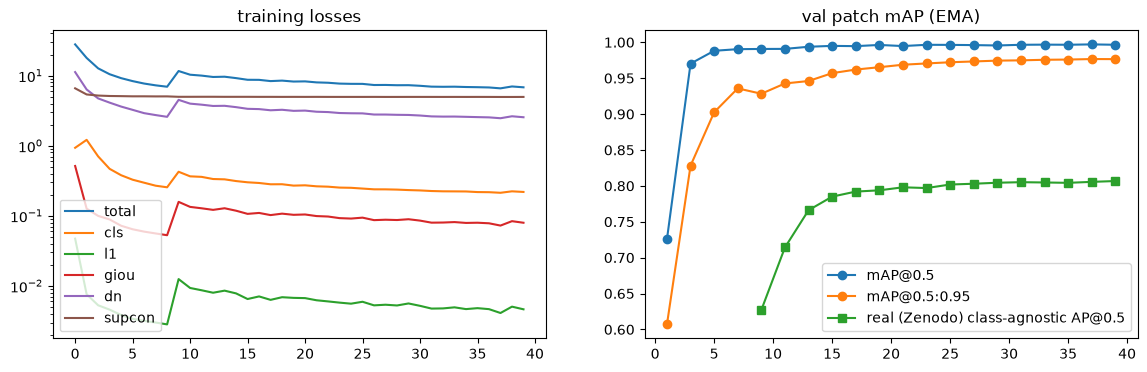

In [16]:
HISTORY = json.load(open(cfg.run_dir / "history.json"))
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for k in ("total", "cls", "l1", "giou", "dn", "supcon", "rel"):
    pts = [(h["epoch"], h[k]) for h in HISTORY if k in h]
    if pts: ax[0].plot(*zip(*pts), label=k)
ax[0].set_yscale("log"); ax[0].legend(); ax[0].set_title("training losses")
ev = [h for h in HISTORY if "val_mAP50" in h]
ax[1].plot([h["epoch"] for h in ev], [h["val_mAP50"] for h in ev], "o-", label="mAP@0.5")
ax[1].plot([h["epoch"] for h in ev], [h["val_mAP"] for h in ev], "o-", label="mAP@0.5:0.95")
zv = [h for h in ev if "val_zen_AP50" in h]
if zv: ax[1].plot([h["epoch"] for h in zv], [h["val_zen_AP50"] for h in zv], "s-", label="real (Zenodo) class-agnostic AP@0.5")
ax[1].legend(); ax[1].set_title("val patch mAP (EMA)"); plt.show()

## 8. Full-sheet inference: tiling → merge → graph → tags → JSON

1. Resize the sheet by `input_scale` (× an optional `pre_scale`) and cut 1024² tiles with 50 % overlap. With `auto_scale=True`,
   a first pass measures the median detected symbol size, and the sheet is re-run at the scale the model was trained on (~72 px
   symbols). This matters for arbitrary real drawings, the same way the Zenodo sheets were normalised.
2. Run PIDFormer on every tile (batched). Each kept query gives a box, class probabilities, an embedding and its decoder state.
3. **Paper merge procedure**: lower each confidence by its distance to an *interior* tile border,
   ĉ = c − α·exp(−3·2d/S) with α = 0.4, so symbols cut by a tile edge lose to their complete copy in a neighbouring tile;
   filter; class-agnostic **Weighted Box Fusion** (fused class = score-weighted mean of class probabilities); a final NMS.
4. **Connections**, from up to three sources merged in the JSON (`methods` field):
   * `relation_head`: Relationformer pairwise edge probabilities per tile, mapped to fused nodes (max over tiles). Used only when
     the checkpoint's relation head was trained on edge labels (Claude pseudo-labels, §3). Untrained, it outputs ~0.5 everywhere.
   * `line_trace`: a crossing-aware line tracer, the paper's modular baseline idea. Symbols and text are erased, ink is split into
     horizontal/vertical runs, and runs meeting at a T/L joint are merged while runs crossing at an X are not. Symbols touching the
     same run network are connected; a network touching ≥ 3 symbols becomes a **junction node** (the paper's crossing/ankle nodes).
   * `claude`: set-of-marks reading by Claude Sonnet 5.5.
5. **Tags**: text *inside* instrument bubbles/boxes is read from an upscaled interior crop (`GLR` / `193` → `GLR-193`). For other
   symbols, sheet-level EasyOCR (0°/90°/270°) finds tag-like labels (`WX-71994`), which are assigned with Hungarian matching on box-gap distance. Optionally **Claude Sonnet 5.5** re-reads tags and connections on a set-of-marks
   overlay of the *detected* boxes, and its answers take priority for tags and are unioned with relation-head edges.
6. Write a JSON file and an overlay PNG to `outputs/`.

In [17]:
def load_model(path=None):
    path = path or cfg.run_dir / "best.pt"
    ck = torch.load(path, map_location=device, weights_only=False)
    m = PIDFormer(cfg, pretrained=False).to(device)
    m.load_state_dict(ck["model"])
    m.relation_trained = bool(ck.get("relation_trained", False))
    return m.eval()

@torch.no_grad()
def detect_sheet(model, gray_native, score_thr=0.05, batch=8, alpha=0.4, pre_scale=1.0):
    s = cfg.input_scale * pre_scale; T = cfg.tile
    img = cv2.resize(gray_native, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    H, W = img.shape
    pos = grid_positions(W, H, T, cfg.infer_stride)
    R = defaultdict(list); rln = []
    for k in range(0, len(pos), batch):
        chunk = pos[k:k + batch]
        x = torch.stack([to_tensor(read_crop(img, x0, y0, T, T)) for x0, y0 in chunk]).to(device)
        with torch.autocast("cuda", dtype=torch.bfloat16):
            out = model(x)
        prob = out["pred_logits"].sigmoid().float()
        boxes = box_cxcywh_to_xyxy(out["pred_boxes"]).clamp(0, 1) * T
        for b, (x0, y0) in enumerate(chunk):
            sc, lb = prob[b].max(-1)
            keep = sc > score_thr
            bx = boxes[b][keep]
            # distance to interior tile borders only (a tile edge lying on the sheet edge cuts nothing)
            big = torch.full_like(bx[:, 0], 1e9)
            d = torch.stack([bx[:, 0] if x0 > 0 else big, bx[:, 1] if y0 > 0 else big,
                             T - bx[:, 2] if x0 + T < W else big, T - bx[:, 3] if y0 + T < H else big], 1).min(1)[0].clamp(min=0)
            R["score"].append(sc[keep] - alpha * torch.exp(-3 * 2 * d / T))
            R["raw_score"].append(sc[keep]); R["label"].append(lb[keep]); R["prob"].append(prob[b][keep])
            R["box"].append((bx + torch.tensor([x0, y0, x0, y0], device=device)) / s)
            R["hs"].append(out["hs"][b][keep].float()); R["emb"].append(out["emb"][b][keep])
            R["tile"].append(torch.full((int(keep.sum()),), k + b, device=device))
            rln.append(out["rln"][b].float())
    dets = {k: torch.cat(v) for k, v in R.items()}
    dets["rln"] = torch.stack(rln)
    dets["tiles"] = torch.tensor([[x0, y0, x0 + T, y0 + T] for x0, y0 in pos], dtype=torch.float32, device=device) / s
    return dets

def merge_tile_detections(dets, min_score=0.05, iou_wbf=0.55, iou_nms=0.5):
    """Paper merge: decayed-score filter -> class-agnostic WBF -> NMS. Returns fused nodes and member->node map."""
    sc = dets["score"]; valid = torch.nonzero(sc >= min_score).squeeze(1)
    order = valid[sc[valid].argsort(descending=True)].tolist()
    boxes, scores, probs = dets["box"].cpu().numpy(), sc.cpu().numpy(), dets["prob"].cpu().numpy()
    fused, members = [], []
    member_of = np.full(len(sc), -1)
    for i in order:
        b = boxes[i]
        if fused:
            F_ = np.array(fused)
            ix1 = np.maximum(F_[:, 0], b[0]); iy1 = np.maximum(F_[:, 1], b[1]); ix2 = np.minimum(F_[:, 2], b[2]); iy2 = np.minimum(F_[:, 3], b[3])
            inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
            iou = inter / ((F_[:, 2] - F_[:, 0]) * (F_[:, 3] - F_[:, 1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter + 1e-6)
            j = int(iou.argmax())
            if iou[j] >= iou_wbf:
                members[j].append(i); member_of[i] = j
                w = scores[members[j]]
                fused[j] = (boxes[members[j]] * w[:, None]).sum(0) / w.sum()
                continue
        fused.append(b.copy()); members.append([i]); member_of[i] = len(fused) - 1
    if not fused:
        return {"boxes": np.zeros((0, 4)), "scores": np.zeros(0), "labels": np.zeros(0, int), "probs": np.zeros((0, cfg.num_classes)),
                "emb": np.zeros((0, cfg.emb_dim))}, member_of
    tiles = dets["tiles"].cpu().numpy(); F_ = np.array(fused)
    cover = ((tiles[None, :, 0] <= F_[:, None, 0]) & (tiles[None, :, 1] <= F_[:, None, 1]) &
             (tiles[None, :, 2] >= F_[:, None, 2]) & (tiles[None, :, 3] >= F_[:, None, 3])).sum(1)
    emb = dets["emb"].float().cpu().numpy()
    f_scores, f_probs, f_emb = [], [], []
    for j, m in enumerate(members):
        w = scores[m]
        f_scores.append(w.sum() / max(cover[j], len(m)))
        f_probs.append((probs[m] * w[:, None]).sum(0) / w.sum())
        e = (emb[m] * w[:, None]).sum(0); f_emb.append(e / (np.linalg.norm(e) + 1e-8))
    f_scores = np.clip(np.array(f_scores), 0, 1); f_probs = np.array(f_probs)
    keep = nms(torch.tensor(F_, dtype=torch.float32), torch.tensor(f_scores, dtype=torch.float32), iou_nms).numpy()
    remap = np.full(len(fused), -1); remap[keep] = np.arange(len(keep))
    member_of = np.where(member_of >= 0, remap[np.maximum(member_of, 0)], -1)
    nodes = {"boxes": F_[keep], "scores": f_scores[keep], "labels": f_probs[keep].argmax(1), "probs": f_probs[keep],
             "emb": np.array(f_emb)[keep]}
    return nodes, member_of

@torch.no_grad()
def relation_edges(model, dets, member_of):
    """Relation-head edge probability between fused nodes (max over tiles)."""
    mo = torch.as_tensor(member_of, device=device)
    best = {}
    for t in range(len(dets["rln"])):
        idx = torch.nonzero((dets["tile"] == t) & (mo >= 0)).squeeze(1)
        if len(idx) < 2: continue
        # one representative member per fused node in this tile (highest score)
        rep = {}
        for i in idx[dets["score"][idx].argsort(descending=True)].tolist():
            rep.setdefault(int(mo[i]), i)
        if len(rep) < 2: continue
        nodes_t, mem_t = list(rep.keys()), torch.tensor(list(rep.values()), device=device)
        ii, jj = torch.triu_indices(len(mem_t), len(mem_t), 1, device=device)
        with torch.autocast("cuda", dtype=torch.bfloat16):
            p = model.relation_logits(dets["hs"][mem_t[ii]], dets["hs"][mem_t[jj]], dets["rln"][t]).sigmoid()
        for a, b, v in zip(ii.tolist(), jj.tolist(), p.tolist()):
            key = (min(nodes_t[a], nodes_t[b]), max(nodes_t[a], nodes_t[b]))
            if v > best.get(key, 0): best[key] = v
    return best

def trace_connections(gray_native, boxes, texts=(), ring=6, gap=15, seg_len=25, arm=12, max_frame_frac=0.85):
    """Line-tracing connectivity (the paper's 'modular' baseline idea, made crossing-aware).
    1. Binarise; erase detected symbols and OCR text; close short gaps (dashed lines) along x and y.
    2. Split ink into horizontal segments, vertical segments and leftovers (diagonals, bends).
    3. Where a horizontal and a vertical segment meet, it is a *crossing* (not connected) if both continue for more than `arm`
       px on both sides, otherwise a T/L *joint* (connected). Leftovers join whatever they touch.
    4. Symbols touching the same joined network are connected; a network touching >= 3 symbols becomes a junction node.
    Returns (pairs, junctions): pairs = {(i, j)} for 2-symbol networks, junctions = [sorted symbol ids] for larger ones."""
    H, W = gray_native.shape
    ink = (gray_native < 128).astype(np.uint8)
    erase = np.zeros_like(ink)
    B = np.asarray(boxes, np.float32).reshape(-1, 4).astype(int)
    for x1, y1, x2, y2 in B: erase[max(0, y1 - 1):y2 + 2, max(0, x1 - 1):x2 + 2] = 1
    for t in texts:
        x1, y1, x2, y2 = map(int, t["box"]); erase[max(0, y1):y2 + 1, max(0, x1):x2 + 1] = 1
    ink[erase > 0] = 0
    k = lambda w, h: cv2.getStructuringElement(cv2.MORPH_RECT, (w, h))
    ink = (cv2.morphologyEx(ink, cv2.MORPH_CLOSE, k(gap, 1)) | cv2.morphologyEx(ink, cv2.MORPH_CLOSE, k(1, gap))) & (1 - erase)
    hor = cv2.morphologyEx(ink, cv2.MORPH_OPEN, k(seg_len, 1)); ver = cv2.morphologyEx(ink, cv2.MORPH_OPEN, k(1, seg_len))
    other = ink & (1 - cv2.dilate(hor | ver, k(5, 5)))
    nh, lh, sh, _ = cv2.connectedComponentsWithStats(hor, connectivity=8)
    nv, lv, sv, _ = cv2.connectedComponentsWithStats(ver, connectivity=8)
    no, lo, so, _ = cv2.connectedComponentsWithStats(other, connectivity=8)
    # global ids: horizontals 1..nh-1, verticals offset, others offset
    off_v, off_o = nh, nh + nv
    parent = list(range(nh + nv + no))
    def find(a):
        while parent[a] != a: parent[a] = parent[parent[a]]; a = parent[a]
        return a
    def union(a, b): parent[find(a)] = find(b)
    dh = cv2.dilate(lh.astype(np.float32), k(5, 5)).astype(np.int32); dv = cv2.dilate(lv.astype(np.float32), k(5, 5)).astype(np.int32)
    ys, xs = np.nonzero((dh > 0) & (dv > 0))
    for a, b in set(zip(dh[ys, xs].tolist(), dv[ys, xs].tolist())):
        hx1, hy, hw = sh[a, 0], sh[a, 1] + sh[a, 3] / 2, sh[a, 2]
        vx, vy1, vh = sv[b, 0] + sv[b, 2] / 2, sv[b, 1], sv[b, 3]
        crossing = (vx - hx1 > arm) and (hx1 + hw - vx > arm) and (hy - vy1 > arm) and (vy1 + vh - hy > arm)
        if not crossing: union(a, off_v + b)
    do = cv2.dilate(lo.astype(np.float32), k(5, 5)).astype(np.int32)
    for lab_map, off in ((lh, 0), (lv, off_v)):
        ys, xs = np.nonzero((do > 0) & (lab_map > 0))
        for a, b in set(zip(do[ys, xs].tolist(), lab_map[ys, xs].tolist())): union(off_o + a, off + b)
    frame = set()
    for stats, off, n in ((sh, 0, nh), (sv, off_v, nv), (so, off_o, no)):
        for i in range(1, n):
            if stats[i, 2] > max_frame_frac * W or stats[i, 3] > max_frame_frac * H: frame.add(find(off + i))
    touch = defaultdict(set)
    for s, (x1, y1, x2, y2) in enumerate(B):
        sl = (slice(max(0, y1 - ring), y2 + ring + 1), slice(max(0, x1 - ring), x2 + ring + 1))
        for lab_map, off in ((lh, 0), (lv, off_v), (lo, off_o)):
            for c in np.unique(lab_map[sl]):
                if c: 
                    r = find(off + int(c))
                    if r not in frame: touch[r].add(s)
    pairs, junctions = set(), []
    for ks in touch.values():
        ks = sorted(ks)
        if len(ks) == 2: pairs.add(tuple(ks))
        elif 3 <= len(ks) <= 16: junctions.append(ks)
    return pairs, junctions

# ---------------- OCR + tag assignment ----------------
_OCR = None
def ocr_sheet(gray_native, win=2048, overlap=256):
    global _OCR
    if _OCR is None:
        import easyocr
        _OCR = easyocr.Reader(["en"], gpu=device.type == "cuda", verbose=False)
    H, W = gray_native.shape; items = []
    for (x0, y0, x1, y1) in som_windows(W, H, win, overlap):
        for poly, text, conf in _OCR.readtext(gray_native[y0:y1, x0:x1], rotation_info=[90, 270], min_size=8, text_threshold=0.6):
            p = np.array(poly, np.float32)
            items.append(([p[:, 0].min() + x0, p[:, 1].min() + y0, p[:, 0].max() + x0, p[:, 1].max() + y0], text.strip(), float(conf)))
    if not items: return []
    b = torch.tensor([i[0] for i in items]); c = torch.tensor([i[2] for i in items])
    return [{"box": items[k][0], "text": items[k][1], "conf": items[k][2]} for k in nms(b, c, 0.4).tolist() if items[k][1]]

def ocr_inside(gray_native, box, inset=0.14, upscale=2.0):
    """Read the text printed inside an instrument bubble/box: crop the interior, upscale, restricted alphabet."""
    x1, y1, x2, y2 = box; w, h = x2 - x1, y2 - y1
    crop = gray_native[int(y1 + inset * h):int(y2 - inset * h), int(x1 + inset * w):int(x2 - inset * w)]
    if crop.size == 0: return ""
    crop = cv2.resize(crop, None, fx=upscale, fy=upscale, interpolation=cv2.INTER_CUBIC)
    crop = cv2.copyMakeBorder(crop, 16, 16, 16, 16, cv2.BORDER_REPLICATE)
    res = _OCR.readtext(crop, allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-", min_size=4, text_threshold=0.5)
    res = sorted(res, key=lambda r: np.mean([p[1] for p in r[0]]))
    return "-".join(normalize_tag(r[1]) for r in res if r[1].strip())

TAG_RE = re.compile(r"^[A-Z]{1,5}-?\d{1,6}(-\d{1,4})?[A-Z]?$")
NO_OUTSIDE_TAG = {CLASS_NAMES.index("flange"), CLASS_NAMES.index("flow_arrow")}

TO_DIGIT = str.maketrans("OQDILZSBT", "001112587")
TO_ALPHA = str.maketrans("01582", "OISBZ")

def normalize_tag(t):
    """Upper-case, unify dashes, and fix O/0, I/1 confusions inside mixed letter/digit segments."""
    t = t.upper().replace(" ", "").replace("_", "-").replace("—", "-").replace("–", "-")
    segs = []
    for seg in t.split("-"):
        nd, na = sum(ch.isdigit() for ch in seg), sum(ch.isalpha() for ch in seg)
        if nd and na: seg = seg.translate(TO_DIGIT) if nd >= na else seg.translate(TO_ALPHA)
        segs.append(seg)
    return "-".join(segs)

def assign_tags(boxes, labels, texts, gray_native=None):
    """Return {node_index: tag}. Instruments: text inside the symbol. Others: Hungarian matching to nearby tag-like labels."""
    tags = {}
    tb = np.array([t["box"] for t in texts], np.float32).reshape(-1, 4)
    tc = (tb[:, :2] + tb[:, 2:]) / 2 if len(tb) else np.zeros((0, 2))
    used = np.zeros(len(texts), bool)
    for i, (b, l) in enumerate(zip(boxes, labels)):
        if SUPER_CLASS[l] != 3: continue
        if len(tb):   # sheet-level text fragments inside the symbol are consumed (not reused as other tags)
            used[(tc[:, 0] > b[0]) & (tc[:, 0] < b[2]) & (tc[:, 1] > b[1]) & (tc[:, 1] < b[3])] = True
        if gray_native is not None:
            t = ocr_inside(gray_native, b)
            if t: tags[i] = t
    cand = [k for k in range(len(texts)) if not used[k] and '"' not in texts[k]["text"] and TAG_RE.match(normalize_tag(texts[k]["text"]))]
    sym = [i for i in range(len(boxes)) if i not in tags and labels[i] not in NO_OUTSIDE_TAG]
    if cand and sym:
        sb = boxes[sym]; ct = tb[cand]
        gx = np.maximum(0, np.maximum(sb[:, None, 0] - ct[None, :, 2], ct[None, :, 0] - sb[:, None, 2]))
        gy = np.maximum(0, np.maximum(sb[:, None, 1] - ct[None, :, 3], ct[None, :, 1] - sb[:, None, 3]))
        size = np.maximum(sb[:, 2] - sb[:, 0], sb[:, 3] - sb[:, 1])[:, None]
        cost = np.hypot(gx, gy) / size
        cost = np.where(cost < 1.0, cost, 1e3)
        r, c = linear_sum_assignment(cost)
        for a, b in zip(r, c):
            if cost[a, b] < 1.0: tags[sym[a]] = normalize_tag(texts[cand[b]]["text"])
    return tags

# ---------------- end-to-end ----------------
def estimate_pre_scale(model, gray, min_nodes=5):
    """Pass 1: detect at native scale, then return the factor that brings the median symbol to cfg.target_symbol_px."""
    nodes, _ = merge_tile_detections(detect_sheet(model, gray))
    b = nodes["boxes"][nodes["scores"] > 0.4]
    if len(b) < min_nodes: return 1.0
    med = np.median(np.maximum(b[:, 2] - b[:, 0], b[:, 3] - b[:, 1]))
    return float(np.clip(cfg.target_symbol_px / med, 0.5, 4.0))

def digitize(img_path, model, use_ocr=True, use_claude=None, save=True, score_thr=None, rel_thr=None,
             pre_scale=1.0, auto_scale=False, use_line_trace=True, use_relation=None):
    score_thr = cfg.score_thr if score_thr is None else score_thr
    rel_thr = cfg.rel_thr if rel_thr is None else rel_thr
    use_claude = CLAUDE_OK if use_claude is None else use_claude
    img_path = Path(img_path)
    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    t0 = time.time()
    if auto_scale:
        pre_scale = estimate_pre_scale(model, gray)
    dets = detect_sheet(model, gray, pre_scale=pre_scale)
    nodes, member_of = merge_tile_detections(dets)
    keep = np.where(nodes["scores"] >= score_thr)[0]
    remap = {int(o): n for n, o in enumerate(keep)}
    boxes, labels, scores = nodes["boxes"][keep], nodes["labels"][keep], nodes["scores"][keep]
    use_relation = getattr(model, "relation_trained", False) if use_relation is None else use_relation
    rel = {(remap[a], remap[b]): p for (a, b), p in relation_edges(model, dets, member_of).items()
           if a in remap and b in remap and p >= rel_thr} if use_relation else {}
    t_det = time.time() - t0
    texts = ocr_sheet(gray) if use_ocr else []
    tags = assign_tags(boxes, labels, texts, gray) if use_ocr else {}
    tag_src = {i: "ocr" for i in tags}
    claude_edges = {}
    if use_claude and len(boxes):
        lab = claude_label_sheet(img_path, boxes, labels, f"pred_{img_path.parent.name}_{img_path.stem}_{len(boxes)}")
        for k, v in lab["tags"].items():
            tags[int(k)] = v; tag_src[int(k)] = "claude"
        for a, b, style, votes in lab["edges"]:
            claude_edges[(min(a, b), max(a, b))] = style
    conns = {}
    def add(e, method, **kw):
        c = conns.setdefault(e, {"source": e[0], "target": e[1], "relation_score": None, "methods": []})
        if method not in c["methods"]: c["methods"].append(method)
        c.update(kw)
    for e, p in rel.items(): add(e, "relation_head", relation_score=round(float(p), 4))
    for e, style in claude_edges.items(): add(e, "claude", style=style)
    junctions = []
    if use_line_trace and len(boxes):
        pairs, groups = trace_connections(gray, boxes, texts)
        for e in pairs: add(e, "line_trace")
        for g in groups:
            jid = f"J{len(junctions)}"
            cen = ((boxes[g, :2] + boxes[g, 2:]) / 2).mean(0)
            junctions.append({"id": jid, "members": [int(i) for i in g], "center": [round(float(v), 1) for v in cen]})
            for i in g: add((int(i), jid), "line_trace")
    nbrs = defaultdict(set)
    jmembers = {j["id"]: j["members"] for j in junctions}
    for a, b in conns:
        if isinstance(b, str):                       # symbol -> junction: connected to every other member
            nbrs[a].update(m for m in jmembers[b] if m != a)
        else:
            nbrs[a].add(b); nbrs[b].add(a)
    equipment = []
    for i, (b, l, s) in enumerate(zip(boxes, labels, scores)):
        x1, y1, x2, y2 = [round(float(v), 1) for v in b]
        equipment.append({
            "id": i, "tag": tags.get(i, ""), "tag_source": tag_src.get(i),
            "class_id": int(l), "class_name": CLASS_NAMES[l], "super_class": SUPER_NAMES[SUPER_CLASS[l]],
            "confidence": round(float(s), 4), "bbox": [x1, y1, x2, y2],
            "center": [round((x1 + x2) / 2, 1), round((y1 + y2) / 2, 1)],
            "connected_to": sorted(nbrs[i]), "connected_tags": [tags.get(j, "") for j in sorted(nbrs[i])],
        })
    result = {"sheet": img_path.name, "image_size": [int(gray.shape[1]), int(gray.shape[0])], "model": "PIDFormer",
              "pre_scale": round(pre_scale, 3), "num_equipment": len(equipment), "num_connections": len(conns), "detection_seconds": round(t_det, 2),
              "equipment": equipment, "junctions": junctions, "connections": list(conns.values())}
    if save:
        json.dump(result, open(cfg.out_dir / f"{img_path.stem}.json", "w"), indent=1)
        cv2.imwrite(str(cfg.out_dir / f"{img_path.stem}_overlay.jpg"), draw_result(gray, result), [cv2.IMWRITE_JPEG_QUALITY, 85])
    return result

SUPER_COLORS = {"general": (0, 160, 0), "valve": (0, 0, 230), "instrumentation": (200, 0, 160), "arrow": (0, 140, 255),
                "tank": (128, 128, 0), "pump": (128, 0, 128), "inlet/outlet": (0, 128, 128)}

def draw_result(gray, result):
    img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    cen = {e["id"]: tuple(int(v) for v in e["center"]) for e in result["equipment"]}
    cen.update({j["id"]: tuple(int(v) for v in j["center"]) for j in result.get("junctions", [])})
    for c in result["connections"]:
        col = (255, 120, 0) if "relation_head" in c["methods"] else (0, 200, 255) if "claude" in c["methods"] else (0, 170, 0)
        cv2.line(img, cen[c["source"]], cen[c["target"]], col, 3)
    for j in result.get("junctions", []):
        cv2.circle(img, cen[j["id"]], 12, (0, 170, 0), -1)
    for e in result["equipment"]:
        x1, y1, x2, y2 = map(int, e["bbox"]); col = SUPER_COLORS[e["super_class"]]
        cv2.rectangle(img, (x1, y1), (x2, y2), col, 3)
        cv2.circle(img, cen[e["id"]], 6, col, -1)
        cv2.putText(img, f"{e['id']}:{e['tag'] or e['class_name'][:10]}", (x1, max(15, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, col, 2)
    return img

{
 "sheet": "2.jpg",
 "image_size": [
  7168,
  4561
 ],
 "model": "PIDFormer",
 "pre_scale": 1.0,
 "num_equipment": 111,
 "num_connections": 122,
 "detection_seconds": 1.18,
 "junctions": [
  {
   "id": "J0",
   "members": [
    0,
    12,
    62
   ],
   "center": [
    679.5,
    3459.8
   ]
  },
  {
   "id": "J1",
   "members": [
    1,
    21,
    29
   ],
   "center": [
    3399.3,
    1236.3
   ]
  },
  {
   "id": "J2",
   "members": [
    2,
    47,
    63
   ],
   "center": [
    1086.6,
    1087.7
   ]
  },
  {
   "id": "J3",
   "members": [
    5,
    13,
    62
   ],
   "center": [
    940.3,
    3607.5
   ]
  },
  {
   "id": "J4",
   "members": [
    7,
    79,
    109
   ],
   "center": [
    2936.8,
    1126.2
   ]
  },
  {
   "id": "J5",
   "members": [
    9,
    50,
    66
   ],
   "center": [
    3494.5,
    3617.3
   ]
  },
  {
   "id": "J6",
   "members": [
    14,
    22,
    59
   ],
   "center": [
    918.7,
    1322.8
   ]
  },
  {
   "id": "J7",
   "members": 

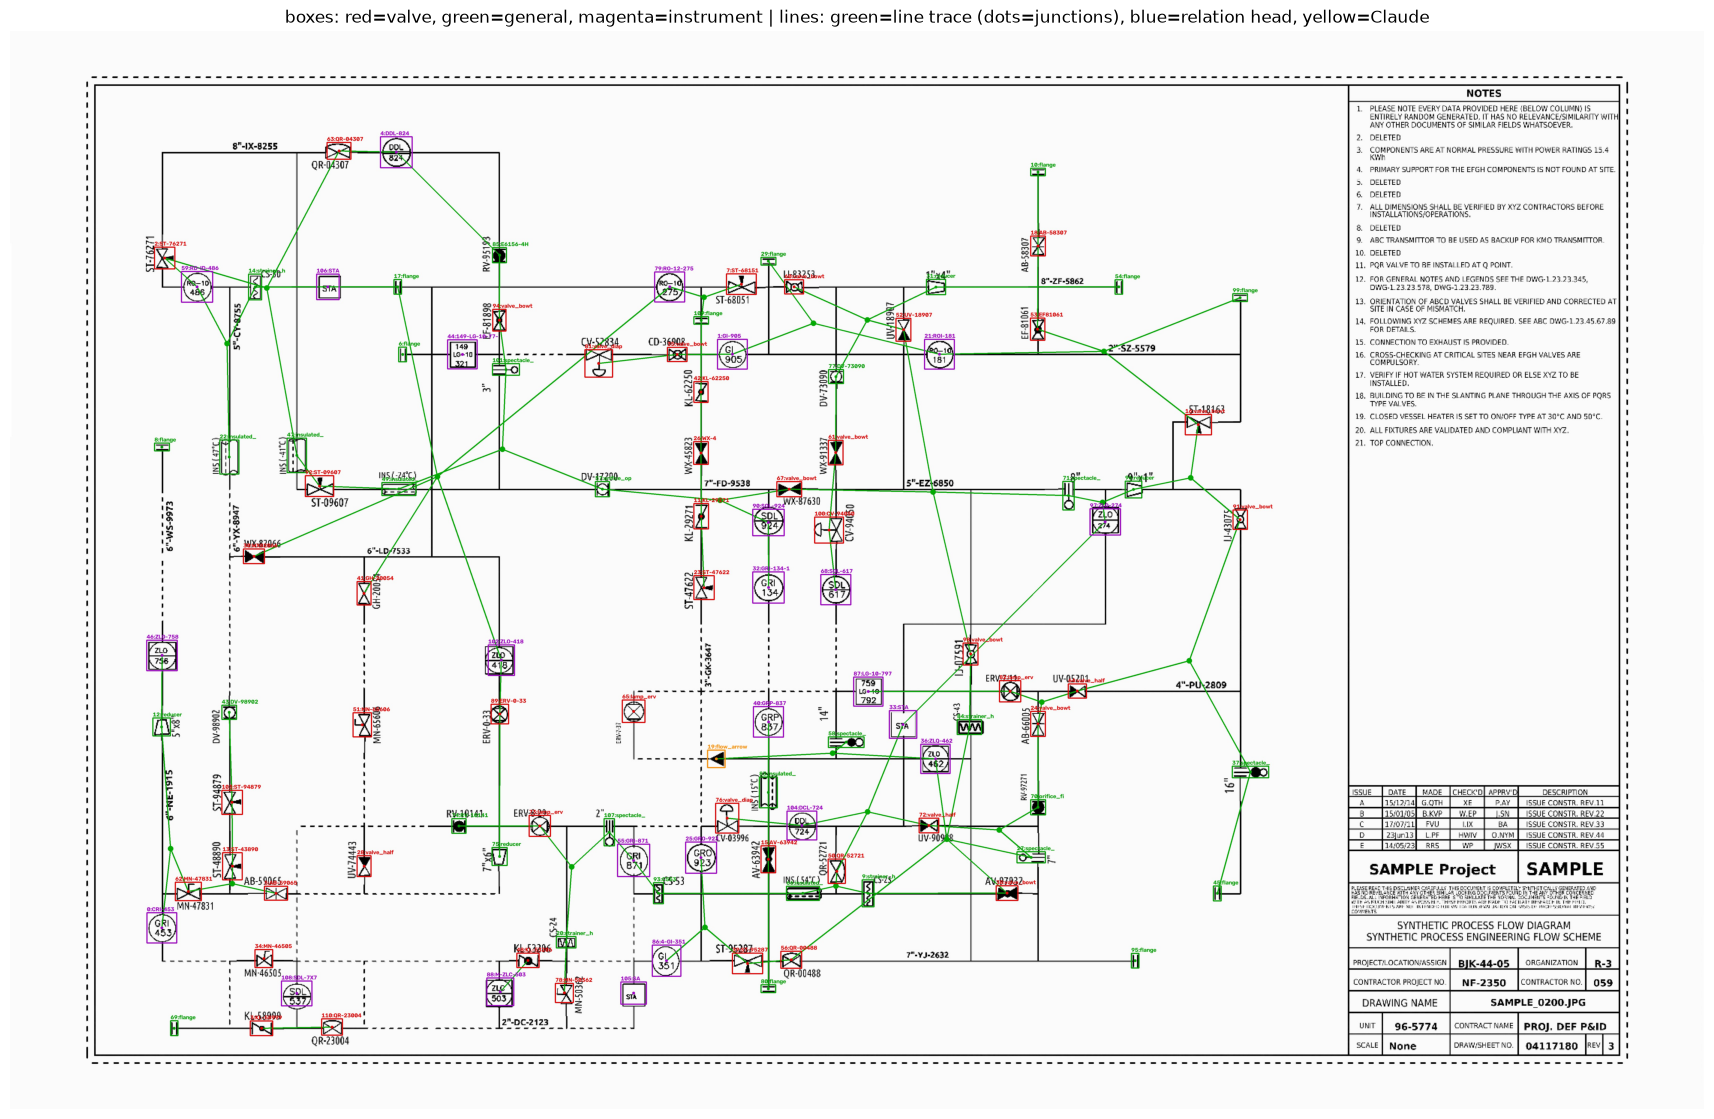

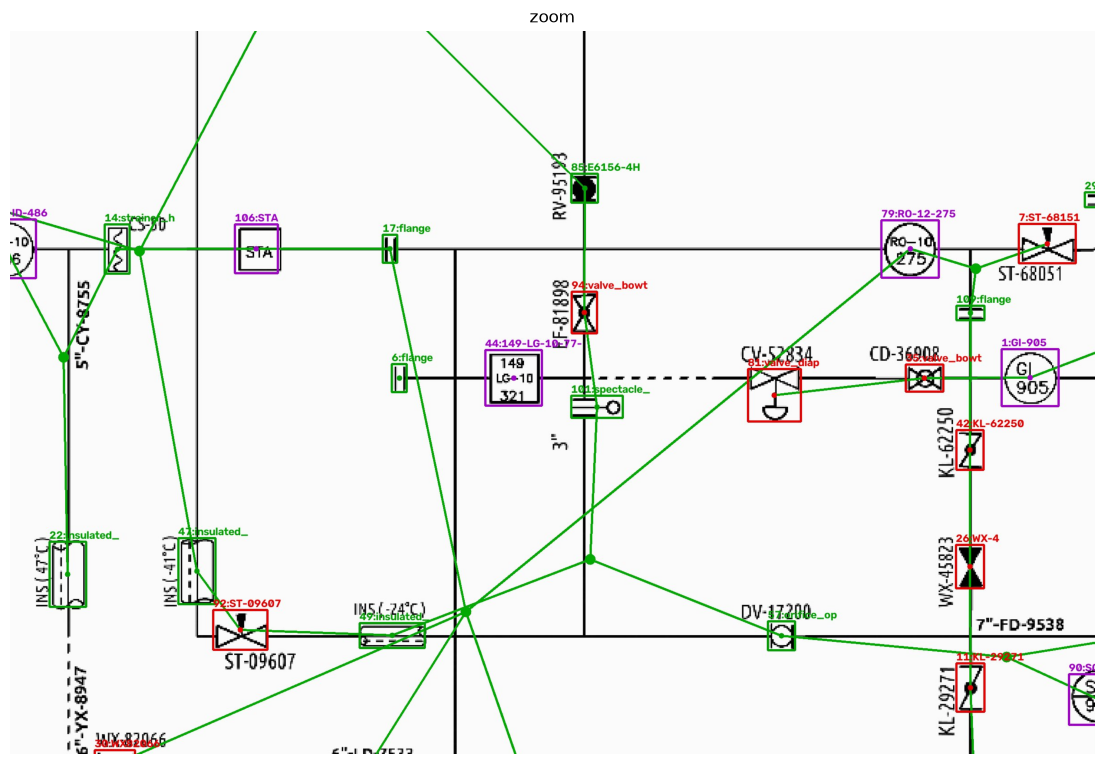

In [18]:
model = load_model()
demo = digitize(VAL[0]["img_path"], model)
print(json.dumps({k: v for k, v in demo.items() if k not in ("equipment", "connections")}, indent=1))
print(json.dumps(demo["equipment"][:5], indent=1))
ov = cv2.imread(str(cfg.out_dir / f"{Path(VAL[0]['img_path']).stem}_overlay.jpg"))
plt.figure(figsize=(22, 14)); plt.imshow(ov[..., ::-1]); plt.axis("off")
plt.title("boxes: red=valve, green=general, magenta=instrument | lines: green=line trace (dots=junctions), blue=relation head, yellow=Claude"); plt.show()
plt.figure(figsize=(14, 10)); plt.imshow(ov[600:2200, 800:3200, ::-1]); plt.axis("off"); plt.title("zoom"); plt.show()

{'sheet': 'z0.jpg', 'image_size': [497, 414], 'model': 'PIDFormer', 'pre_scale': 1.0, 'num_equipment': 11, 'num_connections': 0, 'detection_seconds': 0.34, 'junctions': []}


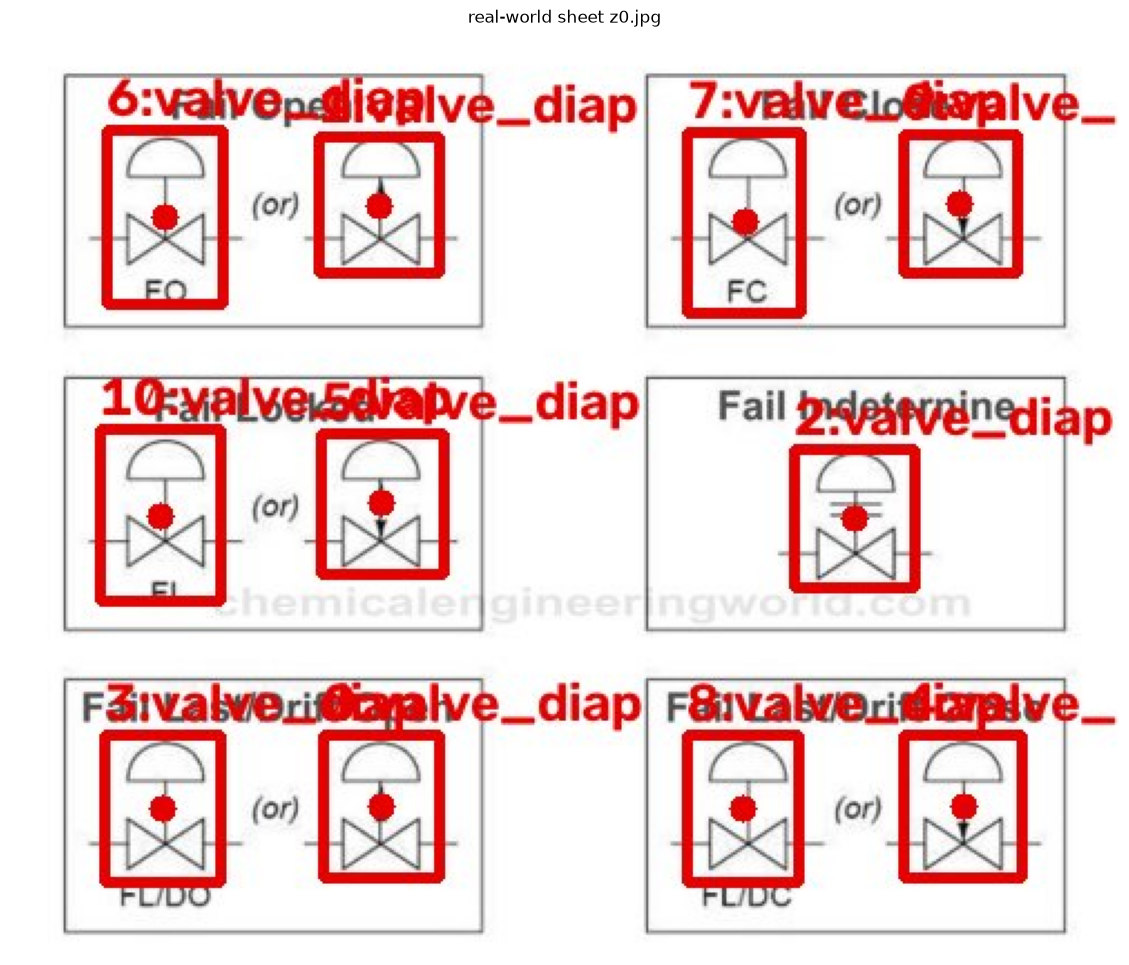

In [19]:
# A real-world sheet (Zenodo val)
demo_z = digitize(VAL_Z[0]["img_path"], model)
print({k: v for k, v in demo_z.items() if k not in ("equipment", "connections")})
ov = cv2.imread(str(cfg.out_dir / f"{Path(VAL_Z[0]['img_path']).stem}_overlay.jpg"))
plt.figure(figsize=(18, 12)); plt.imshow(ov[..., ::-1]); plt.axis("off"); plt.title(f"real-world sheet {VAL_Z[0]['name']}"); plt.show()

## 9. Evaluation (paper metrics)
On the validation sheets after stitching, as in the paper's Table III "Stitched" columns:
* **Symbol mAP@0.5** over the 32 fine classes and over the paper's 7 coarse classes. (mAP@0.5:0.95 is reported at patch level in §7.
  pycocotools caps that summary number at 100 detections per image, and a sheet holds ~120 symbols.)
* **Node AP@0.5**: class-agnostic. Every symbol counts as a node, so a wrong class is not penalised.
* **Edge mAP** (paper Algorithm A1): Hungarian-match predicted nodes to GT nodes (GIoU cost, IoU ≥ 0.5). A predicted edge is a TP
  when its matched GT nodes are connected; missed GT edges are FNs. AP comes from the confidence-ranked precision–recall curve.
  GT edges here are **Claude pseudo-labels** (§3), so the number measures agreement with Claude.

On the real Zenodo val sheets only the class-agnostic **node AP** applies (their boxes carry no symbol class).

Paper reference on Dataset-P&ID (stitched, Relationformer): symbols mAP 76.69, nodes AP 97.72, edges mAP 95.07.
On real drawings (PID2Graph OPEN100), the paper reports node AP 83.63.

In [20]:
def edge_map(pred_boxes, pred_edges, gt_boxes, gt_edges, iou_thr=0.5):
    """pred_edges: {(i,j): score}; gt_edges: set of (i,j). Returns (AP, n_tp, n_fp, n_fn)."""
    if len(gt_edges) == 0: return float("nan"), 0, 0, 0
    pb, gb = torch.tensor(pred_boxes, dtype=torch.float32).reshape(-1, 4), torch.tensor(gt_boxes, dtype=torch.float32).reshape(-1, 4)
    g2p = {}
    if len(pb) and len(gb):
        cost = -generalized_box_iou(gb, pb).numpy(); iou = box_iou(gb, pb).numpy()
        r, c = linear_sum_assignment(cost)
        g2p = {int(a): int(b) for a, b in zip(r, c) if iou[a, b] >= iou_thr}
    p2g = {v: k for k, v in g2p.items()}
    gt_set = {(min(a, b), max(a, b)) for a, b in gt_edges}
    scored = []
    for (a, b), s in pred_edges.items():
        ga, gb_ = p2g.get(a), p2g.get(b)
        tp = ga is not None and gb_ is not None and (min(ga, gb_), max(ga, gb_)) in gt_set
        scored.append((s, tp))
    scored.sort(key=lambda x: -x[0])
    tps = np.cumsum([t for _, t in scored]) if scored else np.zeros(0)
    fps = np.cumsum([not t for _, t in scored]) if scored else np.zeros(0)
    rec = tps / len(gt_set); prec = tps / np.maximum(tps + fps, 1)
    ap = float(np.sum(np.diff(np.concatenate([[0], rec])) * prec)) if len(rec) else 0.0
    n_tp = int(tps[-1]) if len(tps) else 0
    return ap, n_tp, len(scored) - n_tp, len(gt_set) - n_tp

@torch.no_grad()
def evaluate_sheets(model, sheets, with_classes=True):
    m_fine = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", max_detection_thresholds=[1, 10, 1000])
    m_sup = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", max_detection_thresholds=[1, 10, 1000])
    m_node = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", max_detection_thresholds=[1, 10, 1000])
    sup = np.array(SUPER_CLASS); edge_res = []; embs, emb_labels = [], []
    for k, s in enumerate(sheets):
        gray = cv2.imread(s["img_path"], cv2.IMREAD_GRAYSCALE)
        dets = detect_sheet(model, gray)
        nodes, member_of = merge_tile_detections(dets)
        gb = np.array(s["boxes"], np.float32).reshape(-1, 4); gl = np.array(s["labels"])
        P = lambda lab: {"boxes": torch.tensor(nodes["boxes"], dtype=torch.float32).reshape(-1, 4),
                         "scores": torch.tensor(nodes["scores"], dtype=torch.float32), "labels": torch.tensor(lab, dtype=torch.long)}
        G = lambda lab: {"boxes": torch.tensor(gb), "labels": torch.tensor(lab, dtype=torch.long)}
        if with_classes:
            m_fine.update([P(nodes["labels"])], [G(gl)])
            m_sup.update([P(sup[nodes["labels"]])], [G(sup[gl])])
        m_node.update([P(np.zeros(len(nodes["labels"])))], [G(np.zeros(len(gl)))])
        ge = sheet_edges(s)
        if ge is not None:
            rel = relation_edges(model, dets, member_of)
            edge_res.append(edge_map(nodes["boxes"], rel, gb, {tuple(e) for e in ge.tolist()}))
        hi = nodes["scores"] > 0.5
        embs.append(nodes["emb"][hi]); emb_labels.append(nodes["labels"][hi])
        if k % 10 == 0: print(f"  sheet {k+1}/{len(sheets)}", flush=True)
    res = {"node_AP50": m_node.compute()["map_50"].item()}
    if with_classes:
        res.update(symbol_mAP50_32cls=m_fine.compute()["map_50"].item(), symbol_mAP50_7cls=m_sup.compute()["map_50"].item())
    if edge_res:
        res["edge_mAP_vs_claude"] = float(np.nanmean([e[0] for e in edge_res]))
        res["edge_tp_fp_fn"] = [int(sum(e[i] for e in edge_res)) for i in (1, 2, 3)]
    return res, np.concatenate(embs), np.concatenate(emb_labels)

t0 = time.time()
SHEET_METRICS = {}
SHEET_METRICS["synthetic"], EMB, EMB_Y = evaluate_sheets(model, VAL_D[:2] if SMOKE else VAL_D)
SHEET_METRICS["real_zenodo"], _, _ = evaluate_sheets(model, VAL_Z[:2] if SMOKE else VAL_Z, with_classes=False)
print(f"stitched evaluation ({time.time()-t0:.0f}s):")
print(json.dumps(SHEET_METRICS, indent=1))
json.dump(SHEET_METRICS, open(cfg.run_dir / "sheet_metrics.json", "w"), indent=1)

  sheet 1/100


  sheet 11/100


  sheet 21/100


  sheet 31/100


  sheet 41/100


...

  sheet 81/100


  sheet 91/100


  sheet 1/20


  sheet 11/20


stitched evaluation (131s):
{
 "synthetic": {
  "node_AP50": 0.9997926950454712,
  "symbol_mAP50_32cls": 0.9993792176246643,
  "symbol_mAP50_7cls": 0.9975227117538452
 },
 "real_zenodo": {
  "node_AP50": 0.8155378699302673
 }
}


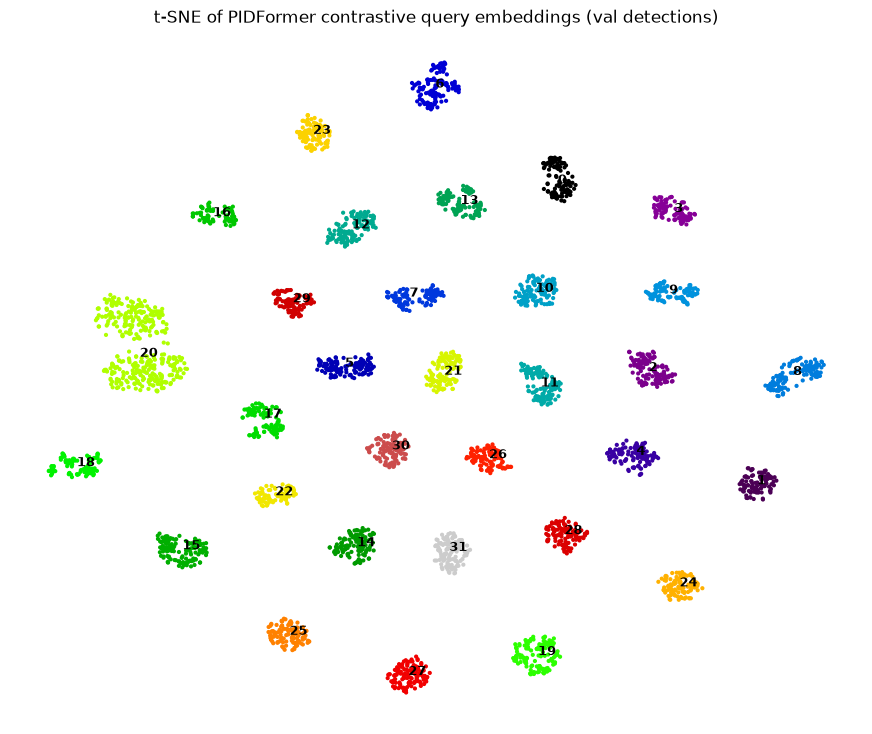

In [21]:
# Contrastive embedding space (compare with the paper's ResNet-feature t-SNE, Fig. A2)
from sklearn.manifold import TSNE
if len(EMB) < 100:
    print("too few confident detections for t-SNE (train longer)")
else:
    sel = np.random.RandomState(0).permutation(len(EMB))[:4000]
    xy = TSNE(n_components=2, init="pca", perplexity=30, random_state=0).fit_transform(EMB[sel])
    plt.figure(figsize=(11, 9))
    plt.scatter(xy[:, 0], xy[:, 1], c=EMB_Y[sel], cmap="nipy_spectral", s=4)
    for c in np.unique(EMB_Y[sel]):
        m = EMB_Y[sel] == c; plt.text(*np.median(xy[m], 0), str(c), fontsize=9, weight="bold")
    plt.title("t-SNE of PIDFormer contrastive query embeddings (val detections)"); plt.axis("off"); plt.show()

## 10. Use on your own P&IDs
```python
model = load_model("runs/pidformer/best.pt")
result = digitize("my_pid.png", model, use_ocr=True, use_claude=True)   # -> outputs/my_pid.json + overlay
for e in result["equipment"]:
    print(e["tag"], e["class_name"], e["center"], "->", e["connected_tags"])
```
**Notes for real drawings.** Use `auto_scale=True` (or pass `pre_scale`) so symbols reach the trained size (~72 px before `input_scale`).
Thanks to the Zenodo sheets the detector also finds symbols outside the 32 synthetic classes (pumps, tanks, …). Their
`class_name` is then the nearest synthetic class with lower confidence. To get real class names, label a few sheets with your
vocabulary and fine-tune (change `cfg.num_classes`); the contrastive embeddings give a good start for new classes.
The Zenodo archive also ships 100-class symbol crops for its test sheets (`3__Stage-2/2__Test_data`), usable for few-shot evaluation.

**Possible next steps.** Pseudo-labels from Claude on more sheets → a better relation head. Self-training on unlabelled real P&IDs
with EMA-teacher pseudo boxes. Line-type classification (solid/dashed) as a second relation class, as in the paper.

In [22]:
# Batch-digitize all validation sheets to JSON
if not SMOKE:
    for s in VAL_D[:5] + VAL_Z[:5]:
        r = digitize(s["img_path"], model, use_claude=False)
        print(s["name"], r["num_equipment"], "equipment,", r["num_connections"], "connections")

2.jpg 111 equipment, 122 connections


5.jpg 93 equipment, 131 connections


6.jpg 118 equipment, 154 connections


8.jpg 109 equipment, 122 connections


11.jpg 107 equipment, 134 connections


z0.jpg 11 equipment, 0 connections


z11.jpg 41 equipment, 28 connections


z15.jpg 42 equipment, 29 connections
z103.jpg 17 equipment, 13 connections


z124.jpg 8 equipment, 0 connections
